In [13]:
# Container-Informationen
!echo "===== Container ID ====="
!echo "Container ID: $(hostname)"

===== Container ID =====
Container ID: codespaces-9946ac


In [14]:
# Betriebssystem
!echo "===== OS Release ====="
!cat /etc/os-release

===== OS Release =====
PRETTY_NAME="Ubuntu 24.04.2 LTS"
NAME="Ubuntu"
VERSION_ID="24.04"
VERSION="24.04.2 LTS (Noble Numbat)"
VERSION_CODENAME=noble
ID=ubuntu
ID_LIKE=debian
HOME_URL="https://www.ubuntu.com/"
SUPPORT_URL="https://help.ubuntu.com/"
BUG_REPORT_URL="https://bugs.launchpad.net/ubuntu/"
PRIVACY_POLICY_URL="https://www.ubuntu.com/legal/terms-and-policies/privacy-policy"
UBUNTU_CODENAME=noble
LOGO=ubuntu-logo


In [15]:
# Aktueller Nutzer
!printf "\n===== Whoami =====\n"
!whoami


===== Whoami =====
jovyan


In [16]:
# uv-Version
!printf "\n===== uv Version =====\n"
!uv --version


===== uv Version =====
uv 0.6.6


In [17]:
# pyflyby-Version
!printf "\n===== pyflyby Version =====\n"
!python -c "import pyflyby; print(pyflyby.__version__)"


===== pyflyby Version =====
1.9.11


In [18]:
# Paket-Versionen in Dockerfile-Reihenfolge anzeigen
pakete = [
    "marimo", "jupyter-marimo-proxy", "jupyterlab-pyflyby", "pyflyby",
    "altair", "hvplot", "matplotlib", "memray", "numba", "numpy",
    "pandas", "plotly", "polars", "pyarrow", "scalene", "scipy", "viztracer"
]

print("===== Paketversionen =====\n")
import importlib.metadata

for paket in pakete:
    try:
        version = importlib.metadata.version(paket)
        print(f"{paket:<22} {version}")
    except importlib.metadata.PackageNotFoundError:
        print(f"{paket:<22} (nicht installiert)")

===== Paketversionen =====

marimo                 0.11.20
jupyter-marimo-proxy   0.0.4
jupyterlab-pyflyby     5.1.2
pyflyby                1.9.11
altair                 5.5.0
hvplot                 0.11.2
matplotlib             3.10.1
memray                 1.16.0
numba                  0.61.0
numpy                  2.1.3
pandas                 2.2.3
plotly                 6.0.0
polars                 1.25.2
pyarrow                19.0.1
scalene                1.5.51
scipy                  1.15.2
viztracer              1.0.3


### Ausschnitt aus Dockerfile zum Vergleich
```Dockerfile
...
  uv pip install \
    # jupyterlab is preinstalled in the base image
    # jupyterlab==4.3.6 \
    # alternative to jupyter notebooks
    marimo==0.11.20 \
    # start marimo notebooks from jupyterlab
    jupyter-marimo-proxy==0.0.4 \
    # try to automatically import missing imports
    jupyterlab-pyflyby==5.1.2 \
    pyflyby==1.9.11 \
    # visualization
    altair==5.5.0 \
    # visualization
    hvplot==0.11.2 \
    # visualization
    matplotlib==3.10.1 \
    # memary profiler (tracer)
    memray==1.16.0 \
    # just-in-time compiler for numerical functions
    numba==0.61.0 \
    # arrays, version set by numba
    numpy \
    # dataframes
    pandas==2.2.3 \
    # visualization
    plotly==6.0.0 \
    # dataframes
    polars==1.25.2 \
    # polars backend, only used for to_pandas() when plotting with hvplot
    pyarrow==19.0.1 \
    # CPU, GPU, and memory profiler (sampler)
    scalene==1.5.51 \
    # algorithms for scientific computing
    scipy==1.15.2 \
    # python tracer
    viztracer==1.0.3 && \
  # load pyflyby automatically
  py pyflyby.install_in_ipython_config_file
  ...

In [19]:
# Import-Test
print("===== Import-Test =====")

for pkg in [
    "marimo", "jupyter_marimo_proxy", "jupyterlab_pyflyby", "pyflyby",
    "altair", "hvplot", "matplotlib", "memray", "numba", "numpy",
    "pandas", "plotly", "polars", "pyarrow", "scalene", "scipy", "viztracer"
]:
    try:
        # Dynamischer Import: lädt ein Modul anhand seines Namens als String
        # Wenn __import__ benutzt wird, muss man das geladene Modul explizit einer Variablen zuweisen
        # Hier wird es nur für die Überprüfung verwendet
        __import__(pkg) 
        print(f"{pkg} kann ohne Probleme importiert werden")
    except ImportError:
        print(f"{pkg} ACHTUNG: PAKET KANN NICHT IMPORTIERT WERDEN")

===== Import-Test =====
marimo kann ohne Probleme importiert werden
jupyter_marimo_proxy kann ohne Probleme importiert werden
jupyterlab_pyflyby kann ohne Probleme importiert werden
pyflyby kann ohne Probleme importiert werden
altair kann ohne Probleme importiert werden
hvplot kann ohne Probleme importiert werden
matplotlib kann ohne Probleme importiert werden
memray kann ohne Probleme importiert werden
numba kann ohne Probleme importiert werden
numpy kann ohne Probleme importiert werden
pandas kann ohne Probleme importiert werden
plotly kann ohne Probleme importiert werden
polars kann ohne Probleme importiert werden
pyarrow kann ohne Probleme importiert werden
scalene kann ohne Probleme importiert werden
scipy kann ohne Probleme importiert werden
viztracer kann ohne Probleme importiert werden


In [20]:
import numpy as np              # Für numerische Operationen und Arrays
import matplotlib.pyplot as plt # Für grafische Darstellung der Ergebnisse
#from math import factorial      # Für die Koeffizienten der Finite-Differenzen-Matrix/Taylor-Matrix
from scipy.special import factorial # Für die Koeffizienten der Finite-Differenzen-Matrix/Taylor-Matrix, geht auch für ganze Arrays!
from scipy.sparse import lil_matrix # https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.lil_matrix.html
from scipy.sparse.linalg import spsolve # https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.linalg.spsolve.html

# Projektarbeit: Die Differentialgleichung der Biegelinie

**Autor:** Ahmed Hossam  
**Zeitraum:** Juni–August 2025  
**Thema:** Analyse und numerische Lösung der Differentialgleichung der Biegelinie elastischer Balken

---

## Einleitung

Diese Projektarbeit behandelt die mathematische Modellierung und Lösung der sogenannten [*Differentialgleichung der Biegelinie*](https://en.wikipedia.org/wiki/Euler%E2%80%93Bernoulli_beam_theory#Static_beam_equation), die das Durchbiegeverhalten elastischer Balken beschreibt. Sie ist ein zentrales Element der Technischen Mechanik und findet breite Anwendung in der Statik und im Maschinenbau.

Die Untersuchung umfasst:

- die **Herleitung** der Biegelinien-Differentialgleichung aus physikalischen Grundlagen,
- die **analytische Lösung einfacher Fälle** (z. B. Balken mit gleichmäßig verteilter Last),
- die **numerische Lösung** mittels Finiter Differenzen sowie unter Verwendung moderner Python-Pakete (`scipy`),
- und die **grafische Darstellung** der Ergebnisse zur Veranschaulichung des Biegeverhaltens (`matplotlib`).

Ziel der Arbeit ist es, sowohl das physikalisch-mathematische Verständnis als auch die praktische Anwendung numerischer Verfahren zur Lösung der Biegelinien-Differentialgleichung zu vertiefen.

---


## Historischer Überblick zur Differentialgleichung der Biegelinie

Die Differentialgleichung der Biegelinie hat ihren Ursprung im 18. Jahrhundert, als erste systematische Ansätze zur Beschreibung der Elastizität und des Biegeverhaltens von Balken entwickelt wurden. Wesentliche Beiträge leisteten insbesondere:

- [**Leonhard Euler (1707–1783)**](https://de.wikipedia.org/wiki/Leonhard_Euler) und [**Daniel Bernoulli (1700–1782)**](https://de.wikipedia.org/wiki/Daniel_Bernoulli), die als Begründer der klassischen Elastizitätstheorie gelten.  
- Euler formulierte die Grundgleichung zur Biegung schlanker Balken, aus der später die [**Euler-Bernoulli-Balkentheorie**](https://de.wikipedia.org/wiki/Balkentheorie) hervorging.  
- Die heute gebräuchliche Form der Differentialgleichung lautet:  
  $$
  EI \frac{d^4 w}{dx^4} = q(x)
  $$  
  Hierbei bezeichnet $w(x)$ die Durchbiegung des Balkens, $EI$ die Biegesteifigkeit (Produkt aus Elastizitätsmodul $E$ und Flächenträgheitsmoment $I$), und $q(x)$ die auf den Balken wirkende Querlast.

Die Euler-Bernoulli-Theorie ermöglichte erstmals eine mathematisch präzise Beschreibung des Durchbiegungsverhaltens elastischer Balken und bildete die Grundlage für moderne Berechnungsmethoden im Bau- und Maschinenwesen. Mit der Weiterentwicklung numerischer Verfahren konnte die Analyse zunehmend komplexerer Strukturen realisiert werden.

Heutzutage stellt die Biegelinien-Differentialgleichung ein fundamentales Werkzeug der Technischen Mechanik dar. Sie wird sowohl analytisch als auch numerisch angewendet, um das Tragverhalten technischer Bauteile mit hoher Genauigkeit zu prognostizieren.

---

## Art der Differentialgleichung und verwandte Beispiele

Die Differentialgleichung der Biegelinie beschreibt die Durchbiegung $w(x)$ eines elastischen Balkens unter einer Querlast $q(x)$ und hat in der Euler-Bernoulli-Theorie die Form:
$$
EI \frac{d^4 w}{dx^4} = q(x)
$$
Hierbei ist:
- $w(x)$ die gesuchte Biegung des Balkens in Abhängigkeit von der Koordinate $x \in [0, L]$,
- $E$ der Elastizitätsmodul (Materialkonstante),
- $I$ das Flächenträgheitsmoment (abhängig von der Querschnittsform),
- $q(x)$ die äußere Belastung (Querlast pro Längeneinheit),
- $EI$ zusammen die konstante Biegesteifigkeit des Balkens.

Die Gleichung wird ergänzt durch geeignete **Randbedingungen**, z. B. feste Einspannungen, gelenkige Lager oder freie Enden. Dadurch ergibt sich ein **Randwertproblem** ([*Boundary Value Problem*](https://de.wikipedia.org/wiki/Randwertproblem), BVP).

### Wesentliche Merkmale

Die Biegelinien-Gleichung ist eine:

- **Gewöhnliche Differentialgleichung (ODE)**:  
  Es handelt sich um eine [gewöhnliche Differentialgleichung](https://de.wikipedia.org/wiki/Gew%C3%B6hnliche_Differentialgleichung), da die gesuchte Funktion $w(x)$ **nur von einer unabhängigen Variablen**, nämlich der Raumkoordinate $x$, abhängt.  
  → Keine partiellen Ableitungen, keine weiteren unabhängigen Variablen wie $t$ (Zeit) oder $y$ (Querkoordinate) treten auf.  
  → Im Gegensatz dazu würde eine **partielle Differentialgleichung (PDE)** mindestens zwei unabhängige Variablen enthalten, z. B. $w(x, t)$.

- **Lineare Differentialgleichung**:  
   Die Differentialgleichung ist **linear** in der gesuchten Funktion $w(x)$, weil sie die folgenden Eigenschaften erfüllt:
  - $w(x)$ und alle Ableitungen ($w''(x)$, $w^{(4)}(x)$ etc.) treten **nicht potenziert**, **nicht multipliziert** untereinander und **nicht in nichtlinearen Funktionen** (wie $\sin(w)$, $\exp(w)$ etc.) auf.
  - Der Operator $L[w] = \frac{d^4 w}{dx^4}$ ist ein **linearer Differentialoperator**, da für beliebige Funktionen $w_1(x)$, $w_2(x)$ und Konstanten $a, b \in \mathbb{R}$ gilt:
    $$
    L[aw_1 + bw_2] = aL[w_1] + bL[w_2]
    $$
  Damit ist die gesamte Gleichung linear im mathematischen Sinne.

- **Differentialgleichung vierter Ordnung**:  Die Differentialgleichung ist **vierter Ordnung**, da die höchste vorkommende Ableitung die vierte Ableitung von $w(x)$ ist, also $w^{(4)}(x)$.

### Randbedingungen

Zur eindeutigen Lösung werden Randbedingungen am linken und rechten Rand ($x = 0$ und $x = L$) benötigt. Beispiele:
- Feste Einspannung: $w(0) = 0$, $w'(0) = 0$
- Freies Ende: $w''(L) = 0$, $w'''(L) = 0$
- Gelenklager: $w(L) = 0$, $M(L) = EI w''(L) = 0$

Diese Bedingungen ergeben sich aus physikalischen Anforderungen wie Zwangsbedingungen, Momenten- oder Kraftfreiheit.


### Bedeutung von Randwertproblemen

Randwertprobleme beschreiben physikalische oder technische Systeme, bei denen die Zustände an mehreren Randpunkten eines Intervalls vorgegeben sind. Die Lösung bestimmt das Verhalten im Inneren des Intervalls. Im Gegensatz zu Anfangswertproblemen (z. B. bei Bewegungsgleichungen) werden hier die Randbedingungen an verschiedenen Stellen, typischerweise an $x = 0$ und $x = L$, spezifiziert.

### Verwandte Beispiele aus Physik und Technik

- **Biegeschwingungen eines Balkens:** Eigenfrequenzen ergeben sich aus homogenen BVPs vierter Ordnung.
- **Stationäre Wärmeleitung:** Temperaturverteilung durch eine lineare BVP zweiter Ordnung.
- **Strömungsmechanik:** Druck- oder Geschwindigkeitsprofile mit vorgegebenen Randwerten.
- **Elektrotechnik:** Elektrische Felder in Wellenleitern mit Randbedingungen an metallischen Flächen.

Das mathematische Verständnis und die numerische Lösung von Randwertproblemen sind essenziell für die Analyse technischer Systeme und bilden ein zentrales Werkzeug in der Technischen Mechanik, der angewandten Mathematik sowie der Physik.

---


## Physikalische Grundlagen

Die Biegelinie $w(x)$ beschreibt die Durchbiegung eines Balkens infolge äußerer Belastungen in Abhängigkeit von der Längsposition $x$. Die Formänderung eines Balkens ergibt sich aus der Wirkung von Querkräften und Momenten entlang seiner Achse. Grundlage der mathematischen Beschreibung ist die klassische **Euler-Bernoulli-Balkentheorie**, die die Biegeverformung schlanker Träger idealisiert.

### Annahmen der Euler-Bernoulli-Theorie

Die Theorie beruht auf den folgenden idealisierenden Annahmen:

- Der Balken ist **schlank**, d. h. seine Länge ist wesentlich größer als seine Querschnittsabmessungen ($L \gg h$).
- **Querschnitte** des Balkens bleiben bei der Biegung **eben** und **normal zur neutralen Faser** (keine Querschnittsverdrehung).
- **Schubverformungen** werden vernachlässigt (reine Biegung).
- Das Material ist **linear-elastisch** und isotrop (Hooke’sches Gesetz gilt).

Diese Voraussetzungen ermöglichen eine vereinfachte, aber dennoch sehr zuverlässige Modellierung von Biegeverhalten in vielen technischen Anwendungen.

### Zusammenhang zwischen Biegemoment und Krümmung

Die zentrale physikalische Größe für die Beschreibung der Balkenbiegung ist das **Biegemoment** $M(x)$. Es steht im direkten Zusammenhang mit der **Krümmung** der Biegelinie:
$$
M(x) = -EI \cdot \frac{d^2 w(x)}{dx^2}
$$

Hierbei bedeuten:

- $w(x)$: Durchbiegung senkrecht zur Balkenachse bei Position $x$,  
- $E$: Elastizitätsmodul des Balkenmaterials (Materialkonstante),  
- $I$: Flächenträgheitsmoment des Balkenquerschnitts (geometrische Eigenschaft),  
- $EI$: Biegesteifigkeit des Balkens.

Die Krümmung $\kappa(x)$ eines Balkens im Sinne der Theorie ergibt sich als:
$$
\kappa(x) = \frac{d^2 w(x)}{dx^2}
$$
Damit folgt direkt:
$$
M(x) = -EI \cdot \kappa(x)
$$

Das negative Vorzeichen ergibt sich aus der Konvention, dass eine positive Durchbiegung nach unten eine negative Krümmung verursacht (bei positivem Moment nach Ingenieursvorzeichenregel).

### Herleitung der Biegelinien-Differentialgleichung

Wird das Momentengleichgewicht auf ein infinitesimales Balkenelement angewendet und mit dem obigen Zusammenhang verknüpft, ergibt sich nach Einbezug der Querlast $q(x)$:
$$
\frac{d^2 M(x)}{dx^2} = q(x)
$$
Einsetzen von $M(x) = -EI \cdot \frac{d^2 w}{dx^2}$ ergibt schließlich:
$$
EI \cdot \frac{d^4 w}{dx^4} = q(x)
$$

Dies ist die **lineare, gewöhnliche Differentialgleichung vierter Ordnung**, die die Biegelinie $w(x)$ bei gegebener Belastung $q(x)$ beschreibt. Sie wird im nächsten Abschnitt numerisch gelöst, da eine exakte analytische Lösung nur in Sonderfällen (z. B. statisch bestimmte Systeme) möglich oder praktikabel ist.

---

## Lösung der Biegelinien-Differentialgleichung

In diesem Abschnitt wird die Differentialgleichung der Biegelinie sowohl **analytisch** (für einfache Lastfälle) als auch **numerisch** gelöst. Zur numerischen Lösung verwenden wir die **Finite-Differenzen-Methode (FDM)**, eine bewährte Technik, bei der Differentialoperatoren durch diskrete Differenzenquotienten approximiert werden.

Die Grundgleichung lautet:
$$
EI \frac{d^4 w}{dx^4} = q(x)
$$
wobei
- $w(x)$ die Durchbiegung des Balkens,
- $q(x)$ die verteilte Querlast,
- $EI$ die Biegesteifigkeit ist.

### Diskretisierung mittels Finite Differenzen

Der Balken der Länge $L$ wird in $N$ gleich große Teilabschnitte mit Schrittweite
$$
h = \frac{L}{N}
$$
unterteilt. An den Diskretisierungspunkten $x_i = i \cdot h$ für $i = 0, \ldots, N$ wird die Funktion $w(x)$ durch den Vektor
$$
\mathbf{w} = \begin{bmatrix} w_0 & w_1 & \cdots & w_N \end{bmatrix}^T
$$
approximiert.

Die vierte Ableitung $w^{(4)}(x)$ wird mit Hilfe zentraler Differenzenquotienten approximiert, z. B. an inneren Punkten durch
$$
w^{(4)}(x_i) \approx \frac{w_{i-2} - 4 w_{i-1} + 6 w_i - 4 w_{i+1} + w_{i+2}}{h^4}
$$

### Lineares Gleichungssystem

Durch Einsetzen der Finite-Differenzen-Approximation in die Differentialgleichung entsteht ein lineares Gleichungssystem der Form:
$$
\mathbf{A} \mathbf{w} = \mathbf{b}
$$
- $\mathbf{A} \in \mathbb{R}^{(N+1) \times (N+1)}$ ist die Koeffizientenmatrix, die die Differenzenoperatoren und Randbedingungen beinhaltet,
- $\mathbf{w} \in \mathbb{R}^{N+1}$ der Vektor der unbekannten Auslenkungen an den Diskretisierungspunkten,
- $\mathbf{b} \in \mathbb{R}^{N+1}$ der Lastvektor mit Werten der Belastung $q(x_i)$ und eventuellen Einflüssen der Randbedingungen.

### Vorgehen

Im Folgenden erfolgt:

1. Die genaue Formulierung der Matrix $\mathbf{A}$ unter Berücksichtigung der Randbedingungen,
2. die Diskretisierung der Belastung $q(x)$ im Vektor $\mathbf{b}$,
3. und schließlich die numerische Lösung des Gleichungssystems mit Python.

---


## Betrachtete Randbedingungen

In dieser Arbeit wird ein Balken unter einer konstant über seine gesamte Länge verteilten Last untersucht. Die Analyse konzentriert sich auf drei grundlegende Lagerungsbedingungen, die häufig in der Praxis vorkommen und verschiedene Randwertprobleme für die Biegelinien-Differentialgleichung repräsentieren:

1. **Beidseitig gelenkig gelagerter Balken:** Beide Enden sind rotationsfrei gelagert, sodass Momentfreiheit an den Lagerstellen vorliegt.  
2. **Linksseitig fest eingespannt, rechts frei:** Das linke Ende ist fest eingespannt (keine Verschiebung und keine Rotation), das rechte Ende ist frei.  
3. **Rechtsseitig fest eingespannt, links frei:** Das rechte Ende ist fest eingespannt, das linke Ende frei.

Diese Fälle bilden typische Randbedingungen ab, die für das Verständnis der Balkenbiegung und deren numerische Behandlung essentiell sind.

## Visualisierung der Randbedingungen

Zur Veranschaulichung der mechanischen Lagerungszustände werden die drei oben genannten Randbedingungen grafisch dargestellt. Die Balken werden als dicke Linien visualisiert, Lagerstellen durch farblich hervorgehobene Rechtecke symbolisiert, und die verteilte Last durch Pfeile entlang des Balkens angezeigt.

Die graphische Darstellung dient der intuitiven Verständnishilfe und stellt die Grundlage für die spätere numerische Analyse der Biegelinien-Differentialgleichung dar. Die verwendeten Parameter für Abmessungen, Farben und Symbole sind flexibel konfigurierbar, um eine klare und anschauliche Präsentation zu gewährleisten.


In [31]:
# --- Physikalische Parameter ---
L = 10      # Länge des Balkens in Metern [m]
E = 2.1e11     # Elastizitätsmodul [Pa]
I = 8.3e-6     # Flächenträgheitsmoment [m^4]
EI = E * I     # Biegesteifigkeit: Produkt aus Elastizitätsmodul E und Flächenträgheitsmoment I [N m^2]

# --- Lastverteilung ---
q0 = 50     # Konstante Streckenlast mit q(x) = q = q0 = 50 [N/m]

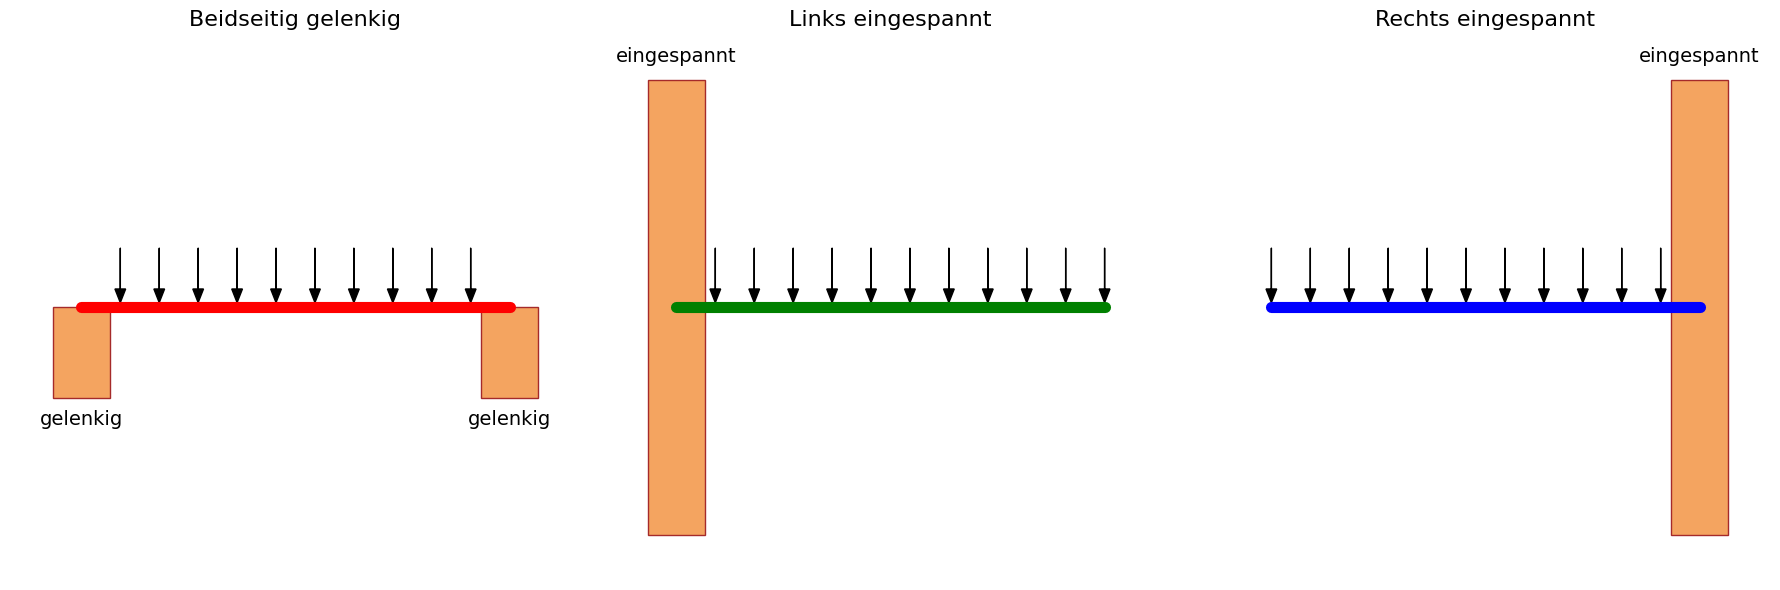

In [22]:
#==================#
# --- Parameter ---#
#==================#

# Allgemeine Abmessungen
x_start = 0                 # Anfang x-Koordinate des Balkens
x_end = 6                   # Ende x-Koordinate des Balkens
y_beam = 0                  # y-Koordinate des Balkens (horizontal)
figsize = (18, 6)           # Größe der Figur

# Balken Eigenschaften
beam_linewidth = 8
beam_capstyle = 'round'
beam_colors = ["red", "green", "blue"]  # Farben der Balken

# Rechtecke (Lager) Eigenschaften
rect_width = 0.8
rect_height_hinge = 1       # Höhe der Rechtecke bei "gelenkig"
rect_height_fixed = 5       # Höhe der Rechtecke bei "eingespannt"
rect_y_hinge = -1           # y-Position der Rechtecke bei "gelenkig"
rect_y_fixed = -2.5         # y-Position der Rechtecke bei "eingespannt"
rect_facecolor = 'sandybrown'
rect_edgecolor = 'brown'

# Pfeile (Kräfte) Eigenschaften
num_arrows = 12
arrow_x_positions = np.linspace(x_start, x_end, num_arrows)  # x-Positionen der Pfeile
arrow_y_start = 0.65
arrow_delta_y = -0.6
arrow_head_width = 0.15
arrow_head_length = 0.15
arrow_facecolor = 'black'
arrow_edgecolor = 'black'

# Text Eigenschaften
text_fontsize = 14
text_y_offset_hinge = -1.3
text_y_offset_fixed = 2.7
title_fontsize = 16

# Achsen Limits
x_limits = (-1, 7)
y_limits = (-3, 3)


#=============#
# --- Plot ---#
#=============#

fig, axs = plt.subplots(1, 3, figsize=figsize)

#============================#
# --- Beidseitig gelenkig ---#
#============================#

axs[0].axis('off')
axs[0].set_xlim(*x_limits)
axs[0].set_ylim(*y_limits)
# Rechtecke links und rechts (gelenkig)
axs[0].add_patch(plt.Rectangle((x_start - rect_width/2, rect_y_hinge), rect_width, rect_height_hinge,facecolor=rect_facecolor, edgecolor=rect_edgecolor))
axs[0].add_patch(plt.Rectangle((x_end - rect_width/2, rect_y_hinge), rect_width, rect_height_hinge,facecolor=rect_facecolor, edgecolor=rect_edgecolor))
# Balken
axs[0].plot([x_start, x_end], [y_beam, y_beam],color=beam_colors[0], lw=beam_linewidth, solid_capstyle=beam_capstyle)
# Pfeile (alle außer erster und letzter)
for x in arrow_x_positions[1:-1]:
    axs[0].arrow(x, arrow_y_start, 0, arrow_delta_y,head_width=arrow_head_width, head_length=arrow_head_length,fc=arrow_facecolor, ec=arrow_edgecolor, length_includes_head=True)
# Texte
axs[0].text(x_start, text_y_offset_hinge, 'gelenkig', ha='center', fontsize=text_fontsize)
axs[0].text(x_end, text_y_offset_hinge, 'gelenkig', ha='center', fontsize=text_fontsize)
axs[0].set_title('Beidseitig gelenkig', fontsize=title_fontsize)

#==========================#
# --- Links eingespannt ---#
#==========================#

axs[1].axis('off')
axs[1].set_xlim(*x_limits)
axs[1].set_ylim(*y_limits)

# Linkes Rechteck (eingespannt)
axs[1].add_patch(plt.Rectangle((x_start - rect_width/2, rect_y_fixed), rect_width, rect_height_fixed,facecolor=rect_facecolor, edgecolor=rect_edgecolor))
axs[1].plot([x_start, x_end], [y_beam, y_beam], color=beam_colors[1], lw=beam_linewidth, solid_capstyle=beam_capstyle)
# Pfeile (alle außer erster)
for x in arrow_x_positions[1:]:
    axs[1].arrow(x, arrow_y_start, 0, arrow_delta_y, head_width=arrow_head_width, head_length=arrow_head_length, fc=arrow_facecolor, ec=arrow_edgecolor, length_includes_head=True)
# Text
axs[1].text(x_start, text_y_offset_fixed, 'eingespannt', ha='center', fontsize=text_fontsize)
axs[1].set_title('Links eingespannt', fontsize=title_fontsize)

#===========================#
# --- Rechts eingespannt ---#
#===========================#

axs[2].axis('off')
axs[2].set_xlim(*x_limits)
axs[2].set_ylim(*y_limits)
# Rechtes Rechteck (eingespannt)
axs[2].add_patch(plt.Rectangle((x_end - rect_width/2, rect_y_fixed), rect_width, rect_height_fixed, facecolor=rect_facecolor, edgecolor=rect_edgecolor))
# Balken
axs[2].plot([x_start, x_end], [y_beam, y_beam], color=beam_colors[2], lw=beam_linewidth, solid_capstyle=beam_capstyle)
# Pfeile (alle außer letzter)
for x in arrow_x_positions[:-1]:
    axs[2].arrow(x, arrow_y_start, 0, arrow_delta_y, head_width=arrow_head_width, head_length=arrow_head_length, fc=arrow_facecolor, ec=arrow_edgecolor, length_includes_head=True)
# Text
axs[2].text(x_end, text_y_offset_fixed, 'eingespannt', ha='center', fontsize=text_fontsize)
axs[2].set_title('Rechts eingespannt', fontsize=title_fontsize)


plt.tight_layout()
plt.show()


In [48]:
# -----------------------------------------------
# Vorbereitung: Diskretisierung
# -----------------------------------------------

# --- Erzeugung der Gitterpunkte ---

N_intervalls = 100              # Anzahl der Unterteilungen des Balkens (Anzahl Gitterintervalle)
N_nodes = N_intervalls + 1      # Anzahl der Gitterpunkte
x = np.linspace(0, L, N_nodes)  # np.linspace erzeugt N_nodes gleichmäßig verteilte Punkte von 0 bis L
                                # Diese entsprechen den Knotenpunkten x_0, x_1, ..., x_N_intervalls
h = x[1] - x[0]                 # Schrittweite h = Abstand zwischen zwei benachbarten Gitterpunkten

In [49]:
def plot_durchbiegung(x, w_expr, beam_color, title, formula_text, text_pos, text_color):
    # w(x) berechnen
    w = w_expr(x)

    # Plot vorbereiten
    plt.figure(figsize=(8, 4))
    plt.plot(x, w, label='Durchbiegung $w(x)$', color=beam_color)
    plt.xlabel('$x$ [m]')
    plt.xlim(0, L)
    plt.ylabel('Durchbiegung $w(x)$ [m]')
    plt.ylim(-0.05 * max(np.abs(w)), 1.05 * max(np.abs(w)))
    plt.title(title)
    plt.grid(True)
    plt.legend()

    # Formeltext einfügen
    plt.text(text_pos[0], text_pos[1] * max(w), formula_text,
             fontsize=14, color=text_color,
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

    # Achse invertieren
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


---

# Analytische Herleitung der Lösung für den Fall eines beidseitig gelenkig gelagerten Balkens

Wir betrachten einen Balken der Länge $L$ mit konstantem Biegesteifigkeitsprodukt $EI$, belastet durch eine konstante, über die Länge verteilte Last $q$. Die Durchbiegung entlang der Längsachse $x \in [0, L]$ wird durch die Biegelinie $w(x)$ beschrieben.

## Differentialgleichung der Biegelinie

Aus der Euler-Bernoulli-Balkentheorie gilt:

$$
EI \frac{d^4 w}{dx^4} = q,
$$

bzw. umgestellt:

$$
\frac{d^4 w}{dx^4} = \frac{q}{EI}.
$$

## Integration der Differentialgleichung

Wir integrieren die Gleichung viermal, um $w(x)$ zu bestimmen:

1. Erste Integration:

$$
\frac{d^3 w}{dx^3} = \int \frac{q}{EI} dx = \frac{q}{EI} x + C_1,
$$

mit Integrationskonstante $C_1$.

2. Zweite Integration:

$$
\frac{d^2 w}{dx^2} = \int \left( \frac{q}{EI} x + C_1 \right) dx = \frac{q}{2 EI} x^2 + C_1 x + C_2,
$$

mit Integrationskonstante $C_2$.

3. Dritte Integration:

$$
\frac{d w}{dx} = \int \left( \frac{q}{2 EI} x^2 + C_1 x + C_2 \right) dx = \frac{q}{6 EI} x^3 + \frac{C_1}{2} x^2 + C_2 x + C_3,
$$

mit Integrationskonstante $C_3$.

4. Vierte Integration:

$$
w(x) = \int \left( \frac{q}{6 EI} x^3 + \frac{C_1}{2} x^2 + C_2 x + C_3 \right) dx = \frac{q}{24 EI} x^4 + \frac{C_1}{6} x^3 + \frac{C_2}{2} x^2 + C_3 x + C_4,
$$

mit Integrationskonstante $C_4$.

Zur Vereinfachung definieren wir neue Konstanten:

$$
C_1' = \frac{C_1}{6}, \quad C_2' = \frac{C_2}{2}, \quad C_3, \quad C_4,
$$

so dass die allgemeine Lösung geschrieben werden kann als

$$
w(x) = \frac{q}{24 EI} x^4 + C_1' x^3 + C_2' x^2 + C_3 x + C_4.
$$

## Randbedingungen für den beidseitig gelenkig gelagerten Balken

Für $x=0$ und $x=L$ gilt:

- Durchbiegung ist null:

$$
w(0) = 0, \quad w(L) = 0,
$$

- Biegemoment ist null, d.h. die zweite Ableitung verschwindet:

$$
w''(0) = 0, \quad w''(L) = 0.
$$

Die zweite Ableitung lautet (unter Verwendung der ursprünglichen Konstanten):

$$
w''(x) = \frac{q}{2 EI} x^2 + 6 C_1' x + 2 C_2'.
$$

## Bestimmung der Integrationskonstanten

1. Aus $w(0)=0$ folgt:

$$
C_4 = 0.
$$

2. Aus $w(L)=0$ folgt:

$$
\frac{q}{24 EI} L^4 + C_1' L^3 + C_2' L^2 + C_3 L + 0 = 0.
$$

3. Aus $w''(0)=0$ folgt:

$$
2 C_2' = 0 \implies C_2' = 0.
$$

4. Aus $w''(L) = 0$ folgt:

$$
\frac{q}{2 EI} L^2 + 6 C_1' L + 0 = 0 \implies 6 C_1' L = - \frac{q}{2 EI} L^2 \implies C_1' = - \frac{q L}{12 EI}.
$$

Setzen wir $C_2' = 0$ und $C_4 = 0$ in Gleichung (2) ein:

$$
\frac{q}{24 EI} L^4 - \frac{q L}{12 EI} L^3 + C_3 L = 0,
$$

was vereinfacht:

$$
\left( \frac{1}{24} - \frac{1}{12} \right) \frac{q L^4}{EI} + C_3 L = 0 \implies - \frac{1}{24} \frac{q L^4}{EI} + C_3 L = 0,
$$

also

$$
C_3 = \frac{q L^3}{24 EI}.
$$

## Endgültige Lösung

Somit ergibt sich für die Durchbiegung $w(x)$

$$
\boxed{
w(x) = \frac{q}{24 EI} x^4 - \frac{q L}{12 EI} x^3 + \frac{q L^3}{24 EI} x,
}
$$

die die Biegelinie eines beidseitig gelenkig gelagerten Balkens unter einer konstanten verteilten Last beschreibt.


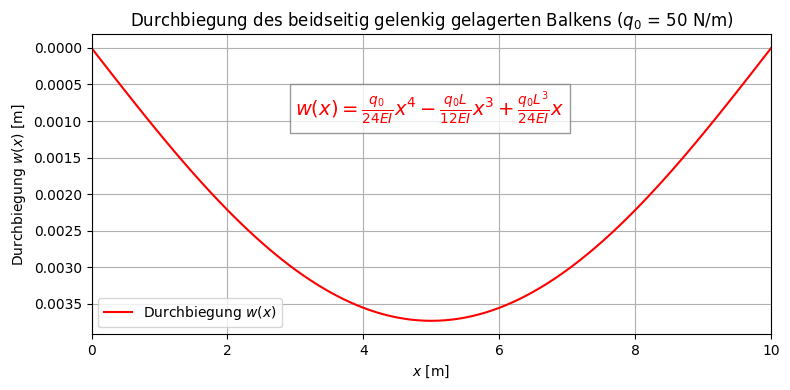

In [47]:
# --- Beidseitig gelenkig ---
plot_durchbiegung(
    x=x,
    w_expr=lambda x: (q0 / (24 * EI)) * x**4 - (q0 * L / (12 * EI)) * x**3 + (q0 * L**3 / (24 * EI)) * x,
    beam_color=beam_colors[0],
    title=f'Durchbiegung des beidseitig gelenkig gelagerten Balkens ($q_0$ = {q0} N/m)',
    formula_text=r'$w(x) = \frac{q_0}{24EI} x^{4} - \frac{q_0L}{12EI} x^{3} + \frac{q_0L^{3}}{24EI} x$',
    text_pos=(0.3 * L, 0.25),
    text_color='red'
)

# Analytische Herleitung der Lösung für den Fall links eingespannt und rechts frei

Wir betrachten einen Balken der Länge $L$ mit konstanter Querschnittsträgheit $EI$, belastet durch eine gleichmäßig verteilte Last $q$. Die Durchbiegung entlang des Balkens wird durch die Funktion $w(x)$ beschrieben.

## Differentialgleichung der Biegelinie

Nach Euler-Bernoulli-Balkentheorie gilt:

$$
EI \frac{d^4 w}{dx^4} = q,
$$

bzw. umgestellt:

$$
\frac{d^4 w}{dx^4} = \frac{q}{EI}.
$$

## Integration der Differentialgleichung

Wir integrieren die Differentialgleichung viermal, um die Durchbiegung $w(x)$ zu erhalten:

1. Erste Integration:

$$
\frac{d^3 w}{dx^3} = \int \frac{q}{EI} \, dx = \frac{q}{EI} x + C_1,
$$

mit Integrationskonstante $C_1$.

2. Zweite Integration:

$$
\frac{d^2 w}{dx^2} = \int \left( \frac{q}{EI} x + C_1 \right) dx = \frac{q}{2 EI} x^2 + C_1 x + C_2,
$$

mit Integrationskonstante $C_2$.

3. Dritte Integration:

$$
\frac{d w}{dx} = \int \left( \frac{q}{2 EI} x^2 + C_1 x + C_2 \right) dx = \frac{q}{6 EI} x^3 + \frac{C_1}{2} x^2 + C_2 x + C_3,
$$

mit Integrationskonstante $C_3$.

4. Vierte Integration:

$$
w(x) = \int \left( \frac{q}{6 EI} x^3 + \frac{C_1}{2} x^2 + C_2 x + C_3 \right) dx = \frac{q}{24 EI} x^4 + \frac{C_1}{6} x^3 + \frac{C_2}{2} x^2 + C_3 x + C_4,
$$

mit Integrationskonstante $C_4$.

Zur Vereinfachung schreiben wir die Lösung als

$$
w(x) = \frac{q}{24 EI} x^4 + C_1' x^3 + C_2' x^2 + C_3 x + C_4,
$$

wobei

$$
C_1' = \frac{C_1}{6}, \quad C_2' = \frac{C_2}{2}.
$$

## Randbedingungen für den Balken mit linksseitiger Einspannung und rechtsfrei

- Bei $x=0$ (eingespannt):

  - Durchbiegung ist null:

  $$
  w(0) = 0,
  $$

  - Neigung ist null (erste Ableitung):

  $$
  w'(0) = 0.
  $$

- Bei $x=L$ (frei):

  - Biegemoment ist null (zweite Ableitung):

  $$
  w''(L) = 0,
  $$

  - Querkraft ist null (dritte Ableitung):

  $$
  w'''(L) = 0.
  $$

## Ableitungen von $w(x)$

Aus der allgemeinen Form ergeben sich

$$
w'(x) = \frac{q}{6 EI} x^3 + 3 C_1' x^2 + 2 C_2' x + C_3,
$$

$$
w''(x) = \frac{q}{2 EI} x^2 + 6 C_1' x + 2 C_2',
$$

$$
w'''(x) = \frac{q}{EI} x + 6 C_1'.
$$

## Einsetzen der Randbedingungen

1. Aus $w(0) = 0$ folgt:

$$
C_4 = 0.
$$

2. Aus $w'(0) = 0$ folgt:

$$
C_3 = 0.
$$

3. Aus $w''(L) = 0$ folgt:

$$
\frac{q}{2 EI} L^2 + 6 C_1' L + 2 C_2' = 0.
$$

4. Aus $w'''(L) = 0$ folgt:

$$
\frac{q}{EI} L + 6 C_1' = 0 \quad \Rightarrow \quad C_1' = -\frac{q L}{6 EI}.
$$

## Bestimmung von $C_2'$

Setze $C_1'$ in die Gleichung für $w''(L)$ ein:

$$
\frac{q}{2 EI} L^2 + 6 \left(-\frac{q L}{6 EI}\right) L + 2 C_2' = 0,
$$

$$
\frac{q}{2 EI} L^2 - \frac{q}{EI} L^2 + 2 C_2' = 0,
$$

$$
-\frac{q}{2 EI} L^2 + 2 C_2' = 0 \quad \Rightarrow \quad C_2' = \frac{q L^2}{4 EI}.
$$

## Endgültige Lösung

Somit lautet die Durchbiegung für den links eingespannten und rechts freien Balken:

$$
\boxed{
w(x) = \frac{q}{24 EI} x^4 - \frac{q L}{6 EI} x^3 + \frac{q L^2}{4 EI} x^2,
}
$$

was die Biegelinie unter der gegebenen Belastung und Randbedingungen vollständig beschreibt.


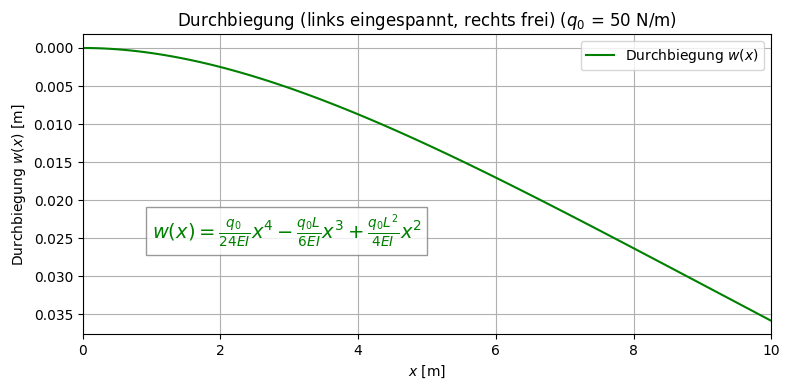

In [50]:
# --- Links eingespannt, rechts frei ---
plot_durchbiegung(
    x=x,
    w_expr=lambda x: (q0 / (24 * EI)) * x**4 - (q0 * L / (6 * EI)) * x**3 + (q0 * L**2 / (4 * EI)) * x**2,
    beam_color=beam_colors[1],
    title=f'Durchbiegung (links eingespannt, rechts frei) ($q_0$ = {q0} N/m)',
    formula_text=r'$w(x) = \frac{q_0}{24EI} x^{4} - \frac{q_0L}{6EI} x^{3} + \frac{q_0L^{2}}{4EI} x^{2}$',
    text_pos=(0.1 * L, 0.7),
    text_color='green'
)

# Analytische Herleitung der Lösung für Balken mit links frei und rechts eingespannt

Wir betrachten denselben Balken der Länge $L$, mit konstantem Biegesteifigkeitsprodukt $EI$ und einer gleichmäßig verteilten Last $q$.

## Differentialgleichung und allgemeine Lösung

Die Durchbiegung $w(x)$ erfüllt die Euler-Bernoulli-Balkengleichung

$$
EI \frac{d^4 w}{dx^4} = q,
$$

bzw.

$$
\frac{d^4 w}{dx^4} = \frac{q}{EI}.
$$

Durch vierfache Integration erhält man die allgemeine Lösung:

$$
w(x) = \frac{q}{24 EI} x^4 + C_1 x^3 + C_2 x^2 + C_3 x + C_4,
$$

mit vier Integrationskonstanten $C_1$, $C_2$, $C_3$ und $C_4$.

## Randbedingungen

Für den Fall **links frei (x=0)** und **rechts eingespannt (x=L)** gelten:

- Links frei ($x=0$):
  - Biegemoment null: $w''(0) = 0$
  - Querkraft null: $w'''(0) = 0$

- Rechts eingespannt ($x=L$):
  - Durchbiegung null: $w(L) = 0$
  - Steifigkeit (erste Ableitung) null: $w'(L) = 0$

## Ableitungen von $w(x)$

\begin{aligned}
w'(x) &= \frac{q}{6 EI} x^3 + 3 C_1 x^2 + 2 C_2 x + C_3, \\
w''(x) &= \frac{q}{2 EI} x^2 + 6 C_1 x + 2 C_2, \\
w'''(x) &= \frac{q}{EI} x + 6 C_1.
\end{aligned}

## Einsetzen der Randbedingungen

1. Aus $w''(0) = 0$ folgt:

$$
2 C_2 = 0 \implies C_2 = 0.
$$

2. Aus $w'''(0) = 0$ folgt:

$$
6 C_1 = 0 \implies C_1 = 0.
$$

3. Aus $w(L) = 0$ folgt:

$$
\frac{q}{24 EI} L^4 + C_3 L + C_4 = 0.
$$

4. Aus $w'(L) = 0$ folgt:

$$
\frac{q}{6 EI} L^3 + C_3 = 0 \implies C_3 = - \frac{q}{6 EI} L^3.
$$

## Bestimmung von $C_4$

Einsetzen von $C_3$ in (3):

$$
\frac{q}{24 EI} L^4 - \frac{q}{6 EI} L^3 \cdot L + C_4 = 0,
$$

was sich vereinfacht zu

$$
\frac{q}{24 EI} L^4 - \frac{q}{6 EI} L^4 + C_4 = 0,
$$

und weiter

$$
-\frac{q}{8 EI} L^4 + C_4 = 0 \implies C_4 = \frac{q}{8 EI} L^4.
$$

## Endgültige Lösung

Somit lautet die Durchbiegung $w(x)$

$$
\boxed{
w(x) = \frac{q}{24 EI} x^4 - \frac{q}{6 EI} L^3 x + \frac{q}{8 EI} L^4,
}
$$

die die Biegelinie eines Balkens mit links frei und rechts eingespannt unter gleichmäßiger Belastung beschreibt.


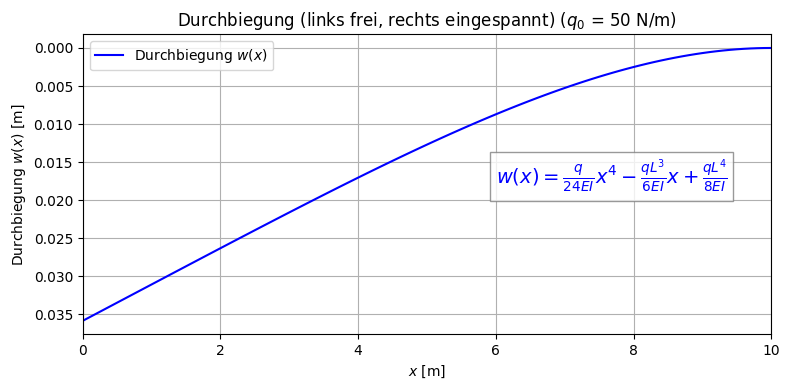

In [51]:
# --- Links frei, rechts eingespannt ---
plot_durchbiegung(
    x=x,
    w_expr=lambda x: (q0 / (24 * EI)) * x**4 - (q0 * L**3 / (6 * EI)) * x + (q0 * L**4 / (8 * EI)),
    beam_color=beam_colors[2],
    title=f'Durchbiegung (links frei, rechts eingespannt) ($q_0$ = {q0} N/m)',
    formula_text=r'$w(x) = \frac{q}{24EI} x^{4} - \frac{qL^{3}}{6EI} x + \frac{qL^{4}}{8EI}$',
    text_pos=(0.6 * L, 0.5),
    text_color='blue'
)

### Analytische Herleitung der Finite-Differenzen-Diskretisierung für die vierte Ableitung

Um die Differentialgleichung der Biegelinie numerisch zu lösen, approximieren wir die Ableitungen durch endliche Differenzen auf einem diskreten Gitter.

**Diskretisierung des Balkens**  
Wir teilen den Balken der Länge $L$ in $N$ gleich große Abschnitte auf, sodass wir die Stützstellen  
$$
x_0, x_1, \ldots, x_N
$$  
mit Abstand  
$$
h = \frac{L}{N}
$$  
erhalten. Die Auslenkung an diesen Punkten schreiben wir als $w_i = w(x_i)$.

---


### Herleitung der Finite-Differenzen-Approximation für die vierte Ableitung

Finite Differenzen basieren auf der Taylorentwicklung einer Funktion $w$ um einen Punkt $x$. Allgemein gilt für ein kleines $h$ und eine beliebige Verschiebung $m \in \mathbb{Z}$:

$$
w(x + m h) = \sum_{k=0}^\infty \frac{w^{(k)}(x)}{k!} m^k h^k
$$

Das bedeutet, der Funktionswert an $x + m h$ lässt sich als unendliche Summe von Ableitungen an $x$ multipliziert mit Potenzen von $m h$ ausdrücken.

Um eine numerische Approximation der vierten Ableitung $w^{(4)}(x)$ zu erhalten, betrachten wir die Taylorreihen von $w$ an den benachbarten Punkten $x \pm h$ und $x \pm 2h$:

$$
\begin{aligned}
w(x + h) &= w(x) + h w'(x) + \frac{h^2}{2} w''(x) + \frac{h^3}{6} w^{(3)}(x) + \frac{h^4}{24} w^{(4)}(x) + O(h^5) \\
w(x - h) &= w(x) - h w'(x) + \frac{h^2}{2} w''(x) - \frac{h^3}{6} w^{(3)}(x) + \frac{h^4}{24} w^{(4)}(x) + O(h^5) \\
w(x + 2h) &= w(x) + 2h w'(x) + 2 h^2 w''(x) + \frac{4 h^3}{3} w^{(3)}(x) + \frac{2 h^4}{3} w^{(4)}(x) + O(h^5) \\
w(x - 2h) &= w(x) - 2h w'(x) + 2 h^2 w''(x) - \frac{4 h^3}{3} w^{(3)}(x) + \frac{2 h^4}{3} w^{(4)}(x) + O(h^5)
\end{aligned}
$$

**Jetzt setzen wir diese Taylorreihen in eine allgemeine Linearkombination ein:**  

$$
a \cdot w(x - 2h) + b \cdot w(x - h) + c \cdot w(x) + d \cdot w(x + h) + e \cdot w(x + 2h)
$$

Dabei ersetzen wir jeden Term durch seine Taylor-Entwicklung um $x$:

$$
\begin{aligned}
& a \left[ w(x) - 2h w'(x) + 2 h^2 w''(x) - \frac{4 h^3}{3} w^{(3)}(x) + \frac{2 h^4}{3} w^{(4)}(x) + \ldots \right] \\
+& b \left[ w(x) - h w'(x) + \frac{h^2}{2} w''(x) - \frac{h^3}{6} w^{(3)}(x) + \frac{h^4}{24} w^{(4)}(x) + \ldots \right] \\
+& c \cdot w(x) \\
+& d \left[ w(x) + h w'(x) + \frac{h^2}{2} w''(x) + \frac{h^3}{6} w^{(3)}(x) + \frac{h^4}{24} w^{(4)}(x) + \ldots \right] \\
+& e \left[ w(x) + 2h w'(x) + 2 h^2 w''(x) + \frac{4 h^3}{3} w^{(3)}(x) + \frac{2 h^4}{3} w^{(4)}(x) + \ldots \right]
\end{aligned}
$$

Nun fassen wir alle Terme zusammen, indem wir nach den Ableitungen von $w$ an der Stelle $x$ gruppieren:

$$
\begin{aligned}
& (a + b + c + d + e) \cdot w(x) \\
+& (-2a - b + d + 2e) \cdot h w'(x) \\
+& \left( 2a + \frac{b}{2} + \frac{d}{2} + 2e \right) \cdot h^2 w''(x) \\
+& \left( -\frac{4}{3} a - \frac{b}{6} + \frac{d}{6} + \frac{4}{3} e \right) \cdot h^3 w^{(3)}(x) \\
+& \left( \frac{2}{3} a + \frac{b}{24} + \frac{d}{24} + \frac{2}{3} e \right) \cdot h^4 w^{(4)}(x) + \ldots
\end{aligned}
$$

Unser Ziel ist, alle Terme außer dem mit $w^{(4)}(x)$ zu eliminieren, also die Koeffizienten der Terme mit $w(x)$, $w'(x)$, $w''(x)$ und $w^{(3)}(x)$ auf null zu setzen. Dadurch erhalten wir eine Approximation für die vierte Ableitung:

$$
\begin{cases}
a + b + c + d + e = 0 \\
-2a - b + d + 2e = 0 \\
2a + \frac{b}{2} + \frac{d}{2} + 2e = 0 \\
-\frac{4}{3} a - \frac{b}{6} + \frac{d}{6} + \frac{4}{3} e = 0 \\
\frac{2}{3} a + \frac{b}{24} + \frac{d}{24} + \frac{2}{3} e = K \neq 0
\end{cases}
$$

Die Lösung lautet:

$$
a = 1, \quad b = -4, \quad c = 6, \quad d = -4, \quad e = 1, \quad K = 1
$$

Damit erhalten wir die finite Differenzen-Formel für die vierte Ableitung:

$$
w^{(4)}(x) \approx \frac{w(x - 2h) - 4 w(x - h) + 6 w(x) - 4 w(x + h) + w(x + 2h)}{h^4} + O(h^2)
$$

Diese Formel verwendet fünf symmetrisch um $x$ verteilte Punkte und ist genau bis zur Ordnung $O(h^2)$. Mit diesem Verfahren lassen sich Differentialgleichungen mit vierter Ableitung diskretisieren und numerisch lösen.

---



### Matrixdarstellung der Finite-Differenzen-Koeffizienten mittels Taylor-Matrix

Die bisherige Herleitung zeigt anschaulich, wie sich die Finite-Differenzen-Koeffizienten für eine konkrete Ableitung aus den Taylorreihen der Funktionswerte an den Stützstellen ergeben.

Dieses Vorgehen lässt sich jedoch elegant und allgemein in eine Matrixform bringen, die für beliebige Ableitungsordnungen und beliebige Verteilungen der Stützstellen funktioniert:

- Sei $x = (x_0, x_1, \ldots, x_{n-1})$ der Vektor der Stützstellen und $x_0$ der Punkt, an dem die Ableitung approximiert werden soll.

- Für jede Ableitungsordnung $k = 0, 1, \ldots, n-1$ und jede Stützstelle $x_i$ definieren wir die Einträge der **Taylor-Matrix** $A$ durch die normierten Taylor-Terme

$$A_{k,i} = \frac{(x_i - x_0)^k}{k!}.$$

- Die gesuchten Finite-Differenzen-Koeffizienten $c = (c_0, c_1, \ldots, c_{n-1})^T$ für die Approximation der $m$-ten Ableitung erhält man, indem man das lineare Gleichungssystem

$$A c = b$$

löst, wobei $b$ der Einheitsvektor ist mit

$$b_k = \begin{cases}
1 & \text{falls } k = m, \\
0 & \text{sonst}.
\end{cases}$$

Diese Gleichung drückt aus, dass wir eine Linearkombination der Funktionswerte an den Stützstellen suchen, die alle Ableitungsanteile außer der gewünschten $m$-ten eliminiert. Das Vorgehen ist numerisch stabil und flexibel: Es funktioniert für ungleichmäßig verteilte Stützstellen und beliebige Ableitungsordnungen. Im folgenden Code wird genau diese Taylor-Matrix konstruiert und das lineare Gleichungssystem gelöst, um die automatische Berechnung der Finite-Differenzen-Koeffizienten zu zeigen.

---


**Schritt: Finite-Differenzen-Approximation der vierten Ableitung**  
Für die vierte Ableitung $\frac{d^4 w}{dx^4}$ an einem inneren Gitterpunkt $x_i$ (mit $2 \leq i \leq N-2$) gilt folgende zentrale Differenzenformel (Genauigkeit $O(h^2)$):

$$
\frac{d^4 w}{dx^4}\bigg|_{x_i} \approx \frac{w_{i-2} - 4 w_{i-1} + 6 w_i - 4 w_{i+1} + w_{i+2}}{h^4}
$$

Diese Formel bezieht die Auslenkungen an fünf benachbarten Punkten mit ein.


**Behandlung der Randpunkte und Ghost Points**  
An den Randpunkten ($i = 0, 1, N-1, N$) ist die direkte Anwendung der obigen Differenzenformel **nicht möglich**, da sie Werte außerhalb des Gitters erfordert (z. B. $w_{-1}$ oder $w_{N+2}$). Solche hypothetischen Punkte werden als *Ghost Points* bezeichnet.

Um dennoch ein geschlossenes Gleichungssystem zu erhalten, werden die Ghost Points durch geeignete Umformung mithilfe der vorgegebenen **Randbedingungen** ersetzt. Typische Randbedingungen (z. B. feste Einspannung, gelenkiges oder freies Lager) liefern Gleichungen, aus denen sich diese Ghost-Werte eliminieren oder durch bekannte Größen ausdrücken lassen.

Alternativ können für die Randpunkte spezielle Differenzenschemata niedrigerer Ordnung oder modifizierte Gleichungen verwendet werden, die direkt die jeweilige Randbedingung abbilden.

**Aufbau eines linearen Gleichungssystems**  
Für jeden inneren Punkt setzen wir die Differentialgleichung

$$
EI \frac{d^4 w}{dx^4} = q(x)
$$

ein und ersetzen die Ableitung durch die finite Differenz:

$$
EI \cdot \frac{w_{i-2} - 4 w_{i-1} + 6 w_i - 4 w_{i+1} + w_{i+2}}{h^4} = q_i
$$

Für alle inneren Punkte zusammen erhalten wir ein lineares Gleichungssystem der Form

$$
EI \mathbf{A} \mathbf{w} = \mathbf{q}
$$

wobei

- $\mathbf{w} = [w_0, w_1, \ldots, w_N]^T$ der Vektor der Auslenkungen an den Gitterpunkten ist,  
- $\mathbf{q} = [q_0, q_1, \ldots, q_N]^T$ die Werte der verteilten Last an den Punkten enthält,  
- und $\mathbf{A}$ eine sogenannte **pentadiagonale Matrix** ist, die die Koeffizienten der Finite-Differenzen enthält und an den Rändern durch die Randbedingungen angepasst wird.

---

Mit diesem Verständnis können wir nun konkret die Matrix $\mathbf{A}$ aufbauen und das Gleichungssystem numerisch lösen.

## Aufbau der Biegesteifigkeitsmatrix $A$ mittels Finiter Differenzen

Zur Lösung der Biegungsgleichung eines schlanken Balkens

$$
EI \cdot w^{(4)}(x) = q(x)
$$

wird die Ableitung vierter Ordnung durch ein zentrales Finite-Differenzen-Schema approximiert. Dies führt auf ein lineares Gleichungssystem der Form

$$
A \cdot \vec{w} = \vec{q}
$$

wobei $\vec{w}$ der Vektor der gesuchten Verschiebungen an diskreten Gitterpunkten $x_0, x_1, \dots, x_{N-1}$ ist und $\vec{q}$ die diskretisierte Lastfunktion darstellt.

### Diskretisierung der vierten Ableitung

Für die inneren Knotenpunkte $i = 2, \dots, N-3$ wird die vierte Ableitung durch die sogenannte 5-Punkt-Formel ersetzt:

$$
w^{(4)}(x_i) \approx \frac{w_{i-2} - 4w_{i-1} + 6w_i - 4w_{i+1} + w_{i+2}}{h^4}
$$

Daraus ergibt sich für diese Knoten die folgende Struktur der Matrix $A$:

- Hauptdiagonale: $6$
- Nebendiagonalen: $-4$ (links und rechts daneben)
- Zwei Diagonalen weiter außen: $1$ (links und rechts)

Diese Koeffizienten werden mit $\frac{EI}{h^4}$ skaliert.


### Behandlung der Randbedingungen

Die äußeren Zeilen der Matrix $A$ (also Zeilen $0$, $1$ und $N-2$, $N-1$) werden abhängig von der Randlagerung modifiziert, um bestimmte physikalische Randbedingungen zu erzwingen. Folgende Typen sind implementiert:

| Randbedingung           | Linkes Ende                       | Rechtes Ende                      | Kommentar zur Randbedingung                        |
|------------------------|----------------------------------|----------------------------------|---------------------------------------------------|
| **beidseitig gelenkig**| $w(0) = 0$ <br> $w''(0) = 0$    | $w(L) = 0$ <br> $w''(L) = 0$    | Beide Enden sind gelenkig gelagert <br> (keine Verschiebung, kein Moment) |
| **nur links eingespannt** | $w(0) = 0$ <br> $w'(0) = 0$    | $w''(L) = 0$ <br> $w'''(L) = 0$ | Links feste Einspannung <br> (keine Verschiebung und Rotation), <br> rechts frei (kein Moment, keine Scherkraft) |
| **nur rechts eingespannt**| $w''(0) = 0$ <br> $w'''(0) = 0$ | $w(L) = 0$ <br> $w'(L) = 0$    | Rechts feste Einspannung, <br> links frei <br> (Moment- und Scherkraftfreiheit) |

---

### Finite-Differenzen-Approximationen: zentral, vorwärts und rückwärts

Finite-Differenzen sind numerische Methoden, um Ableitungen anhand diskreter Werte einer Funktion $w_i = w(x_i)$ zu approximieren. Dabei stehen verschiedene Arten von Differenzen zur Verfügung:

- **Vorwärtsdifferenz:**  
  Nutzt Werte an $x_i$ und den nächsten Punkten rechts davon (z.B. $x_{i+1}$, $x_{i+2}$).  
  Vorteil: Einfach am linken Rand anzuwenden, da Punkte rechts vorhanden sind.  
  Beispiel für erste Ableitung:  
  $w'(x_0) \approx \frac{w_1 - w_0}{h}$  
  (für höhere Genauigkeit gibt es auch erweiterte Formeln, siehe unten)

- **Rückwärtsdifferenz:**  
  Nutzt Werte an $x_i$ und Punkten links davon (z.B. $x_{i-1}$, $x_{i-2}$).  
  Vorteil: Gut am rechten Rand anwendbar, wenn keine Werte rechts verfügbar sind.  
  Beispiel für erste Ableitung:  
  $w'(x_{N-1}) \approx \frac{w_{N-1} - w_{N-2}}{h}$

- **Zentrale Differenz:**  
  Nutzt Werte symmetrisch links und rechts von $x_i$ (z.B. $x_{i-1}$ und $x_{i+1}$).  
  Vorteil: Höhere Genauigkeit, da symmetrisch.  
  Beispiel für zweite Ableitung:  
  $w''(x_i) \approx \frac{w_{i-1} - 2 w_i + w_{i+1}}{h^2}$

---

### Analytische Herleitungen der Finite-Differenzen-Randbedingungen

Die folgenden Randbedingungen wurden mit Hilfe der Taylorreihenentwicklung der Funktion $w(x)$ an den Rändern des Balkens hergeleitet. Für Ableitungen werden Vorwärts- und Rückwärtsdifferenzen verwendet, je nachdem, ob man sich am linken oder rechten Rand befindet. Der Gitterabstand sei konstant mit $h$.

---


## Fall 1: Beidseitig gelenkig gelagert  
**Randbedingungen:**
- Linkes Ende: $w(0) = 0$, $w''(0) = 0$
- Rechtes Ende: $w(L) = 0$, $w''(L) = 0$

### Herleitung von $w(0) = 0$  
Dies ist eine Dirichlet-Randbedingung:  
Der Funktionswert ist am linken Rand direkt bekannt.  
$\Rightarrow w_0 = 0$

### Herleitung von $w''(0) = 0$ (Vorwärtsdifferenz 2. Ordnung)

Entwickle $w(x)$ an den Punkten $x_1 = h$ und $x_2 = 2h$ um $x_0 = 0$:

- $w_1 = w_0 + h w_0' + \frac{h^2}{2} w_0'' + \frac{h^3}{6} w_0''' + \dots$
- $w_2 = w_0 + 2h w_0' + 2h^2 w_0'' + \frac{4h^3}{3} w_0''' + \dots$

Subtrahiere $2 \cdot$ (erste Gleichung) von der zweiten:

- $w_2 - 2 w_1 + w_0 = h^2 w_0'' + \mathcal{O}(h^3)$

$\Rightarrow w''(0) \approx \frac{w_0 - 2 w_1 + w_2}{h^2} = 0$

### Herleitung von $w(L) = 0$  
Ebenfalls Dirichlet-Bedingung:  
$\Rightarrow w_{N-1} = 0$

### Herleitung von $w''(L) = 0$ (Rückwärtsdifferenz 2. Ordnung)

Entwickle um $x_{N-1}$ rückwärts:

- $w_{N-2} = w_{N-1} - h w_{N-1}' + \frac{h^2}{2} w_{N-1}'' - \frac{h^3}{6} w_{N-1}''' + \dots$
- $w_{N-3} = w_{N-1} - 2h w_{N-1}' + 2h^2 w_{N-1}'' - \frac{4h^3}{3} w_{N-1}''' + \dots$

Ergibt:

- $w_{N-1} - 2 w_{N-2} + w_{N-3} = h^2 w_{N-1}'' + \mathcal{O}(h^3)$

$\Rightarrow w''(L) \approx \frac{w_{N-1} - 2 w_{N-2} + w_{N-3}}{h^2} = 0$

---


## Fall 2: Nur links eingespannt  
**Randbedingungen:**
- Linkes Ende: $w(0) = 0$, $w'(0) = 0$
- Rechtes Ende: $w''(L) = 0$, $w'''(L) = 0$

### Herleitung von $w(0) = 0$  
Dirichlet-Randbedingung:  
$\Rightarrow w_0 = 0$

### Herleitung von $w'(0) = 0$ (Vorwärtsdifferenz 2. Ordnung)

Entwickle:

- $w_1 = w_0 + h w_0' + \frac{h^2}{2} w_0'' + \dots$
- $w_2 = w_0 + 2h w_0' + 2h^2 w_0'' + \dots$

Linearkombination:

- $-3 w_0 + 4 w_1 - w_2 = 2h w_0' + \mathcal{O}(h^3)$

$\Rightarrow w'(0) \approx \frac{-3 w_0 + 4 w_1 - w_2}{2h} = 0$

### Herleitung von $w''(L) = 0$ (Rückwärtsdifferenz)

Wie oben:

$\Rightarrow w''(L) \approx \frac{w_{N-1} - 2 w_{N-2} + w_{N-3}}{h^2} = 0$

### Herleitung von $w'''(L) = 0$ (Rückwärtsdifferenz 3. Ordnung)

Entwickle rückwärts:

- $w_{N-4} = w_{N-1} - 3h w_{N-1}' + \frac{9h^2}{2} w_{N-1}'' - \frac{9h^3}{2} w_{N-1}''' + \dots$
- $w_{N-3} = w_{N-1} - 2h w_{N-1}' + 2h^2 w_{N-1}'' - \frac{4h^3}{3} w_{N-1}''' + \dots$
- $w_{N-2} = w_{N-1} - h w_{N-1}' + \frac{h^2}{2} w_{N-1}'' - \frac{h^3}{6} w_{N-1}''' + \dots$

Kombination:

- $-w_{N-4} + 3 w_{N-3} - 3 w_{N-2} + w_{N-1} = h^3 w_{N-1}''' + \mathcal{O}(h^4)$

$\Rightarrow w'''(L) \approx \frac{-w_{N-4} + 3 w_{N-3} - 3 w_{N-2} + w_{N-1}}{h^3} = 0$

---

## Fall 3: Nur rechts eingespannt  
**Randbedingungen:**
- Linkes Ende: $w''(0) = 0$, $w'''(0) = 0$
- Rechtes Ende: $w(L) = 0$, $w'(L) = 0$

### Herleitung von $w''(0) = 0$  
Wie in Fall 1:

$\Rightarrow w''(0) \approx \frac{w_0 - 2 w_1 + w_2}{h^2} = 0$

### Herleitung von $w'''(0) = 0$ (Vorwärtsdifferenz 3. Ordnung)

Entwickle:

- $w_1 = w_0 + h w_0' + \frac{h^2}{2} w_0'' + \frac{h^3}{6} w_0''' + \dots$
- $w_2 = w_0 + 2h w_0' + 2h^2 w_0'' + \frac{4h^3}{3} w_0''' + \dots$
- $w_3 = w_0 + 3h w_0' + \frac{9h^2}{2} w_0'' + \frac{9h^3}{2} w_0''' + \dots$

Kombination:

- $-w_0 + 3 w_1 - 3 w_2 + w_3 = h^3 w_0''' + \mathcal{O}(h^4)$

$\Rightarrow w'''(0) \approx \frac{-w_0 + 3 w_1 - 3 w_2 + w_3}{h^3} = 0$

### Herleitung von $w(L) = 0$  
Dirichlet:  
$\Rightarrow w_{N-1} = 0$

### Herleitung von $w'(L) = 0$ (Rückwärtsdifferenz 2. Ordnung)

Wie bei $w'(0)$, nur rückwärts:

- $w'(L) \approx \frac{3 w_{N-1} - 4 w_{N-2} + w_{N-3}}{2h} = 0$

---

### Randbedingungen und Finite-Differenzen-Approximationen

Je nach gewählter Randbedingung werden unterschiedliche Finite-Differenzen-Formeln zur Umsetzung der physikalischen Randbedingungen verwendet.

---

#### 1. Fall: links und rechts gelenkig, d.h. verschiebungsfrei und gekrümmt frei

- **Links (x=0):**

  - Verschiebung:  
    $$
    w(0) = w_0 = 0
    $$

  - Zweite Ableitung (Krümmung):  
    $$
    w''(0) \approx \frac{w_0 - 2 w_1 + w_2}{h^2} = 0
    $$

- **Rechts (x=L):**

  - Verschiebung:  
    $$
    w(L) = w_{N-1} = 0
    $$

  - Zweite Ableitung (Krümmung):  
    $$
    w''(L) \approx \frac{w_{N-3} - 2 w_{N-2} + w_{N-1}}{h^2} = 0
    $$

---

#### 2. Fall: links fest eingespannt, rechts frei

- **Links (x=0):**

  - Verschiebung:  
    $$
    w(0) = w_0 = 0
    $$

  - Erste Ableitung (Rotation):  
    $$
    w'(0) \approx \frac{-3 w_0 + 4 w_1 - w_2}{2 h} = 0
    $$

- **Rechts (x=L):**

  - Zweite Ableitung (Krümmung):  
    $$
    w''(L) \approx \frac{w_{N-3} - 2 w_{N-2} + w_{N-1}}{h^2} = 0
    $$

  - Dritte Ableitung (Scherkraft):  
    Die dritte Ableitung wird rückwärts differenziert mit einer **4-Punkt-Formel**:  
    $$
    w'''(L) \approx \frac{-w_{N-4} + 3 w_{N-3} - 3 w_{N-2} + w_{N-1}}{h^3} = 0
    $$

  - **Wichtig:** Im verwendeten Code wird hier die Variante mit den Koeffizienten $-1, 3, -3, 1$ (ohne Faktor 1/2) verwendet, also die Formel mit Nenner $h^3$, nicht die alternative Variante mit Koeffizienten $-1, 2, -2, 1$ und Nenner $2 h^3$. 

---

#### 3. Fall: links frei, rechts fest eingespannt

- **Links (x=0):**

  - Zweite Ableitung (Krümmung):  
    $$
    w''(0) \approx \frac{w_0 - 2 w_1 + w_2}{h^2} = 0
    $$

  - Dritte Ableitung (Scherkraft):  
    Die dritte Ableitung wird vorwärts differenziert mit einer **4-Punkt-Formel**:  
    $$
    w'''(0) \approx \frac{-w_0 + 3 w_1 - 3 w_2 + w_3}{h^3} = 0
    $$

- **Rechts (x=L):**

  - Verschiebung:  
    $$
    w(L) = w_{N-1} = 0
    $$

  - Erste Ableitung (Rotation):  
    $$
    w'(L) \approx \frac{3 w_{N-1} - 4 w_{N-2} + w_{N-3}}{2 h} = 0
    $$

---

### Zusammenfassung zu den Dritten Ableitungen

| Randbedingung        | Stelle      | Formel für $w'''$                           | Formel im Code                          |
|----------------------|-------------|--------------------------------------------|---------------------------------------|
| NUR_LINKS_EINGESPANNT | rechts (L)  | $\displaystyle \frac{-w_{N-4} + 3 w_{N-3} - 3 w_{N-2} + w_{N-1}}{h^3} = 0$ | wie oben (4-Punkt Rückwärtsdifferenz) |
| NUR_RECHTS_EINGESPANNT| links (0)   | $\displaystyle \frac{-w_0 + 3 w_1 - 3 w_2 + w_3}{h^3} = 0$                | wie oben (4-Punkt Vorwärtsdifferenz)  |

---

Diese Formeln sichern die korrekte Umsetzung der physikalischen Randbedingungen:

- Eingespannte Enden: Verschiebung und Rotation bzw. Rotation oder Verschiebung (je nach Rand).
- Freie Enden: Krümmung und Scherkraft (zweite und dritte Ableitung) gleich Null.

---


In [52]:
def build_taylor_matrix(x, x0, n):
    """
    Erzeugt die Taylor-Matrix A für Finite-Differenzen-Koeffizienten.

    Jeder Eintrag A[i,j] entspricht (x[j] - x0)^i / i! für i,j = 0..n-1.

    Parameter:
    ----------
    x : array_like, Form (n,)
        Stützstellenpunkte.
    x0 : float
        Auswertungspunkt.
    n : int
        Anzahl der Stützstellen (Matrixgröße).

    Rückgabe:
    ---------
    A : ndarray, Form (n, n)
        Taylor-Matrix.

    """

    A = np.zeros((n, n))     # Taylor-Matrix A: beschreibt Entwicklung um x0

    # orders: array von [0, 1, 2, ..., n-1], initial 1D-Array mit Länge n
    orders = np.arange(n)

    # reshape(-1, 1):
    # - Der Parameter '-1' bedeutet, dass numpy die passende Anzahl Zeilen automatisch bestimmt
    #   basierend auf der Gesamtzahl der Elemente und der angegebenen Anzahl Spalten.
    # - '1' steht für eine Spalte.
    #
    # Ergebnis: orders wird zu einer 2D-Matrix mit n Zeilen und 1 Spalte (also ein Spaltenvektor).
    # Beispiel: orders.shape vor reshape = (n,), nach reshape = (n, 1)
    orders = orders.reshape(-1, 1)

    # diffs: (x - x0) ist 1D-Array mit n Elementen
    diffs = (x - x0)

    # reshape(1, -1):
    # - '1' bedeutet genau 1 Zeile.
    # - '-1' sagt numpy, die passende Anzahl Spalten automatisch zu bestimmen.
    # Ergebnis: diffs wird zu einer 2D-Matrix mit 1 Zeile und n Spalten (also ein Zeilenvektor).
    # Beispiel: diffs.shape vor reshape = (n,), nach reshape = (1, n)
    diffs = diffs.reshape(1, -1)

    # Nun erzeugen wir die Potenzen:
    # numpy broadcastet die Formen (n,1) und (1,n) zu (n,n)
    # Jeder Eintrag powers[i,j] = (x[j] - x0)^i
    powers = np.power(diffs, orders)

    # Fakultäten als Spaltenvektor (n x 1) zur Division
    factorials = factorial(orders)

    # Division der Potenzen durch i! (elementweise)
    A = powers / factorials

    return A


In [53]:
def finite_diff_coeffs(x, x0, m):
    """
    Berechnet Finite-Differenzen-Koeffizienten zur Approximation der m-ten
    Ableitung einer Funktion f an der Stelle x0 mit gegebenen Stützstellen x.

    Hintergrund:
    Die Methode basiert auf der Taylorentwicklung:
        f(x + mh) = Σ_{k=0}^∞ (f^{(k)}(x) / k!) · (mh)^k

    Für eine Approximation der m-ten Ableitung an x0 wählen wir eine Linearkombination
    der Funktionswerte f(x_i) mit Gewichtungen c_i, sodass alle Terme der Taylorreihe
    bis auf den gewünschten Ableitungsterm f^{(m)}(x0) ausgelöscht werden.

    Mathematisch führt dies auf ein lineares Gleichungssystem:

        A @ c = b

    wobei:
        A_{k,i} = (x[i] - x0)^k / k!   (normierte Taylor-Matrix)
        b_k     = 1 falls k == m, sonst 0

    Lösung:
        Der Vektor c enthält die Koeffizienten der Finite-Differenzen-Formel:
            f^{(m)}(x0) ≈ Σ c_i · f(x_i)
    """

    n = len(x)               # Anzahl der Stützstellen, bestimmt Größe des LGS

    if m >= n:
        raise ValueError("m (Ableitungsordnung) muss kleiner sein als die Anzahl der Stützstellen n")

    b = np.zeros(n)          # Rechte Seite b: erzeugt Kronecker-Delta für m-te Ableitung

    # Aufbau der Taylor-Matrix:
    # A[k, i] entspricht dem normierten k-ten Term der Taylor-Entwicklung
    # von f(x_i) um die Stelle x0
    A = build_taylor_matrix(x, x0, n)

    # Setze rechten Vektor b so, dass nur der m-te Ableitungsterm übrig bleibt
    b[m] = 1.0

    # Lösung des linearen Gleichungssystems: ergibt die gesuchten FD-Koeffizienten
    return np.linalg.solve(A, b)


In [16]:
def print_fd(name, x, x0, m, denom_factor=1, rev=False):
    """
    Druckt eine Finite-Differenzen-Formel für die m-te Ableitung einer Funktion w
    an der Stelle x0, basierend auf den Stützstellen x.

    Parameter:
    - name         : String zur Beschreibung der Formel (z.B. "w'(0), vorwärts")
    - x            : Array mit Stützstellen (z.B. [-2h, -h, 0, h, 2h])
    - x0           : Auswertestelle für die Ableitung (häufig 0 oder Randpunkt)
    - m            : Ordnung der abzuleitenden Ableitung (1 = erste Ableitung usw.)
    - denom_factor : Faktor im Nenner (z.B. 2 bei Schrittweite 2h statt h)
    - rev          : Bool, falls True werden Indizes der Koeffizienten umgedreht,
                     um z.B. rückwärts gerichtete Formeln korrekt darzustellen

    Ausgabe:
    Eine lesbare Formel der Form:
      w^{(m)}(x0) ≈ (c0·w0 + c1·w1 + ...) / (denom_factor·h^m)
    """

    # Berechnung der Finite-Differenzen-Koeffizienten für die m-te Ableitung
    # an der Stelle x0 mit den Stützstellen x.
    # Anschließend wird der Koeffizientenvektor mit dem Faktor denom_factor
    # multipliziert, um z.B. größere Schrittweiten (2h statt h) korrekt zu berücksichtigen.
    c = finite_diff_coeffs(x, x0, m) * denom_factor

    terms = []  # Liste zur Speicherung der einzelnen Summanden der Formel

    # Bestimmung der Reihenfolge der Indizes:
    # - normal von 0 bis len(c)-1, falls rev=False
    # - umgekehrt von len(c)-1 bis 0, falls rev=True
    # Dies ist wichtig, damit bei rückwärts gerichteten Formeln
    # die Indizes der Funktionswerte korrekt angezeigt werden.
    inds = reversed(range(len(c))) if rev else range(len(c))

    # Iteration über alle Koeffizienten gemäß der gewählten Index-Reihenfolge
    for i in inds:
        # Ignoriere numerisch sehr kleine Koeffizienten (unter 1e-12)
        if abs(c[i]) < 1e-12:
            continue

        # Formatierung des Koeffizienten:
        # - Falls der Koeffizient praktisch ganzzahlig ist, wird er als Integer angezeigt
        # - Ansonsten mit 2 Dezimalstellen (z.B. 1.33)
        if abs(c[i] - round(c[i])) < 1e-12:
            val = int(round(abs(c[i])))
        else:
            val = f"{abs(c[i]):.2f}"

        # Bestimmung des Vorzeichens "+" oder "-"
        sign = "+" if c[i] > 0 else "-"

        # Aufbau des Summanden als String, z.B. "+4·w2" oder "-1·w0"
        terms.append(f"{sign}{val}·w{i}")

    # Entferne das führende "+" vom ersten Summanden für bessere Lesbarkeit,
    # falls der erste Koeffizient positiv ist
    if terms and terms[0].startswith("+"):
        terms[0] = terms[0][1:]

    # Konstruktion des Nenners:
    # - Wenn denom_factor ungleich 1, z.B. "2·h^1"
    # - Sonst einfach "h^m"
    denom = f"{denom_factor}·h^{m}" if denom_factor != 1 else f"h^{m}"

    # Ausgabe der kompletten Formel
    print(f"{name} (Ableitung {m}):\n  ({' '.join(terms)}) / {denom}\n")


# Beispielhafte Schrittweite (kann angepasst werden)
h = 1.0

# Definition der Stützstellen für die erste Ableitung mit Schrittweite h
x1 = np.array([0, h, 2*h])

# Ausgabe der vorwärts gerichteten Finite-Differenzen-Formel für w'(0)
print_fd("w'(0), vorwärts", x1, 0, 1, denom_factor=2)

# Ausgabe der rückwärts gerichteten Finite-Differenzen-Formel für w'(L)
# Hier werden die Stützstellen umgedreht (x1[::-1]) und die Indizes ebenfalls
# (rev=True), um die Koeffizienten passend zum rückwärtsgerichteten Schema anzuzeigen.
print_fd("w'(L), rückwärts", x1[::-1], 2*h, 1, denom_factor=2, rev=True)

# Analog für die zweite Ableitung (w'') vorwärts und rückwärts
print_fd("w''(0), vorwärts", x1, 0, 2)
print_fd("w''(L), rückwärts", x1[::-1], 2*h, 2, rev=True)

# Stützstellen für dritte Ableitung vorwärts (vier Punkte)
x3_fwd = np.array([0, h, 2*h, 3*h])
print_fd("w'''(0), vorwärts", x3_fwd, 0, 3)

# Für rückwärts gerichtete dritte Ableitung:  
# 1. Stützstellen sortiert aufsteigend und relativ zu x0=0 verschoben,
#    sodass 3*h (der Punkt L) die neue Nullstelle ist.
x3_back = np.array([0, h, 2*h, 3*h]) - 3*h
print_fd("w'''(L), rückwärts", x3_back, 0, 3, rev=True)

# Stützstellen für vierte Ableitung, zentral (symmetrisch um 0)
x4 = np.array([-2*h, -h, 0, h, 2*h])
print_fd("w''''(i), zentral", x4, 0, 4)


w'(0), vorwärts (Ableitung 1):
  (-3·w0 +4·w1 -1·w2) / 2·h^1

w'(L), rückwärts (Ableitung 1):
  (1·w2 -4·w1 +3·w0) / 2·h^1

w''(0), vorwärts (Ableitung 2):
  (1·w0 -2·w1 +1·w2) / h^2

w''(L), rückwärts (Ableitung 2):
  (1·w2 -2·w1 +1·w0) / h^2

w'''(0), vorwärts (Ableitung 3):
  (-1·w0 +3·w1 -3·w2 +1·w3) / h^3

w'''(L), rückwärts (Ableitung 3):
  (1·w3 -3·w2 +3·w1 -1·w0) / h^3

w''''(i), zentral (Ableitung 4):
  (1·w0 -4·w1 +6·w2 -4·w3 +1·w4) / h^4



Diese Formeln werden in die Randzeilen der Matrix $A$ eingesetzt, um die jeweiligen Randbedingungen direkt im linearen Gleichungssystem zu erzwingen.

### Numerische Berechnung

Die Funktion `build_bending_matrix(...)` erzeugt eine $(N \times N)$-Matrix $A$, die das Differentialproblem

$$
EI \cdot w^{(4)}(x) = q(x)
$$

diskretisiert. Durch Lösen des Gleichungssystems

$$
A \vec{w} = \vec{q}
$$

kann die Biegelinie $\vec{w}$ numerisch berechnet werden.

In [54]:
# --- Lastverteilung ---
q = q0 * np.ones(N_nodes)

In [55]:
def build_bending_matrix(N_nodes, h, EI, q_c, boundary_condition="beidseitig_gelenkig"):
    """
    Erzeugt die Biegesteifigkeitsmatrix A für einen Balken, die Diskretisierung
    der Gleichung EI * w'''' = q(x) mit der Finite-Differenzen-Methode.

    Parameter:
    - N_nodes: Anzahl der Gitterpunkte
    - h: Abstand zwischen den Gitterpunkten
    - EI: Biegesteifigkeit (konstant)
    - q_c: Lastvektor (kopiert)
    - boundary_condition: Randbedingung als String, möglich:
        * "beidseitig_gelenkig": w=0 und w''=0 an beiden Enden
        * "nur_links_eingespannt": links w=0, w'=0; rechts w''=0, w'''=0
        * "nur_rechts_eingespannt": links w''=0, w'''=0; rechts w=0, w'=0

    Rückgabe:
    - A: (N x N)-Matrix zur Diskretisierung von EI * w'''' = q
    - q: Angepasster Lastvektor 

    """

    if boundary_condition == "beidseitig_gelenkig" and N_nodes < 5:
        raise ValueError("Mindestens 5 Punkte für 'beidseitig_gelenkig' erforderlich!")
    elif "eingespannt" in boundary_condition and N_nodes < 6:
        raise ValueError("Mindestens 6 Punkte für eingespannten Rand erforderlich!")

    if EI <= 0:
        raise ValueError("EI muss größer 0 sein!")

    A = lil_matrix((N_nodes, N_nodes), dtype=np.float64) # https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.lil_matrix.html

    # ===========================
    # 1. Diskretisierung im Inneren
    # ===========================
    # Für innere Punkte i=2 ... N-3 (weil wir 2 Nachbarn links und rechts brauchen)
    # Diskretisierung der 4. Ableitung mit Standard-Finite-Differenzen:
    # w''''(x_i) ≈ (w_{i-2} - 4 w_{i-1} + 6 w_i - 4 w_{i+1} + w_{i+2}) / h^4

    start_idx = 2
    end_idx = N_nodes - 2

    # Indexbereich der Matrix, der mit Finite-Differenzen beschrieben werden darf
    indices = np.arange(start_idx, end_idx) # 2, 3, ..., N - 3

    # Diskretisierung der 4. Ableitung
    A[indices, indices - 2] = 1 / h**4
    A[indices, indices - 1] = -4 / h**4
    A[indices, indices    ] = 6 / h**4
    A[indices, indices + 1] = -4 / h**4
    A[indices, indices + 2] = 1 / h**4

    # ===========================
    # 2. Randbedingungen
    # ===========================

    # Hier setzen wir die Randbedingungen direkt in der Matrix A um.
    # WICHTIG: Dies überschreibt die entsprechenden Zeilen in A,
    # um die Randwerte (Dirichlet oder Ableitungen) exakt vorzugeben.
    #
    # Dabei gilt: A @ w = q
    # - w ist der Vektor der Verschiebungen an den Gitterpunkten
    # - q ist der Vektor der äußeren Lasten (belastungsabhängig)
    #
    # Wenn z.B. w(0) = 0 vorgegeben ist, setzen wir die erste Zeile von A so,
    # dass nur w_0 darin auftaucht, und die rechte Seite q[0] muss dann auch 0 sein.
    # Somit erzwingen wir im Gleichungssystem w_0 = 0 unabhängig von der Last.
    #
    # Dadurch wird das lineare System korrekt gelöst, auch an den Rändern,
    # wo sonst Ableitungen auf Punkte außerhalb des Gitters zugreifen würden.

    # Randbedingungen

    match boundary_condition:
        case "beidseitig_gelenkig":
            # A ist nicht symmetrisch im mathematischen Sinne (A[i,j]==A[j,i]), da es sich um physikalische Gleichungen handelt!
        # --- Linke Randbedingung: w(0) = 0 ---
            # Wir wollen erzwingen, dass die Verschiebung (w) am linken Rand exakt 0 ist.
            # Das bedeutet: w_0 = 0, wobei w_0 die Verschiebung am ersten Gitterpunkt ist.
            #
            # Unser System ist A @ w = q, mit A als Matrix, w als Vektor der unbekannten Verschiebungen.
            #
            # Um im linearen Gleichungssystem w_0 = 0 sicherzustellen, stellen wir die erste Zeile so ein,
            # dass sie nur diese Variable betrifft:
            #    1 * w_0 + 0 * w_1 + 0 * w_2 + ... = 0
            #
            # In Matrixform: A[0,:] = [1, 0, 0, ..., 0] und rechte Seite q[0] = 0.
            #
            # Dadurch wird beim Lösen des Systems der Wert w_0 genau auf 0 gesetzt,
            # unabhängig von anderen Gleichungen.
            #
            # Ohne diese explizite Festlegung könnte das System versuchen,
            # w_0 anhand der Differentialgleichung zu bestimmen,
            # was an den Rändern ohne Stützpunkte „außerhalb“ des Bereichs nicht sinnvoll ist.
            #
            # Beispiel:
            #   Für ein System mit 3 Punkten wäre die erste Zeile der Matrix:
            #     [1, 0, 0]
            #   Die erste Gleichung: w_0 = 0
            #
            # w(0) = 0 (Verschiebung am linken Rand)
            # Matrixzeile wird zu: 1 * w_0 = 0
            A[0, :] = 0
            A[0, 0] = 1

            # Rechte Seite (q) an dieser Stelle muss 0 sein, um w_0=0 zu erzwingen
            q_c[0] = 0 

        # --- Linke Randbedingung: w''(0) = 0 ---
            # Zweite Ableitung an x=0 soll 0 sein.
            #
            # Die zweite Ableitung approximieren wir mit einer 3-Punkte-Formel, da
            # außerhalb des Bereichs keine Punkte liegen (keine negativen Indizes).
            #
            # Die Formel lautet:
            #   w''(x_0) ≈ (w_0 - 2*w_1 + w_2) / h²
            #
            # Diese Approximation ist zweite Ordnung genau und benutzt nur Punkte im Bereich.
            #
            # Die Gleichung lautet also:
            #   (w_0 - 2 w_1 + w_2) / h² = 0
            #
            # Das setzen wir in die zweite Zeile der Matrix ein:
            A[1, :] = 0
            A[1, 0] = 1 / h**2
            A[1, 1] = -2 / h**2
            A[1, 2] = 1 / h**2

            # rechte Seite q[1] muss ebenfalls 0 sein
            q_c[1] = 0
            
        # --- Rechte Randbedingung: w(L) = 0 ---
            # Verschiebung am rechten Ende (x = L) soll exakt 0 sein.
            # Das heißt: w_{N-1} = 0, wobei N-1 der Index des letzten Gitterpunkts ist.
            #
            # Um das sicherzustellen, setzen wir die letzte Zeile der Matrix so,
            # dass nur die Variable w_{N-1} beteiligt ist:
            #    0 * w_0 + ... + 1 * w_{N-1} = 0
            #
            # Dadurch wird bei der Lösung w_{N-1} = 0 garantiert.
            #
            # Beispiel:
            #   Für ein System mit N=5 Gitterpunkten (Index 0..4) ist die letzte Zeile:
            #     [0, 0, 0, 0, 1]
            #   Die Gleichung: w_4 = 0
            A[-1, :] = 0
            A[-1, -1] = 1

            # (rechte Seite q[-1] muss 0 sein)
            q_c[-1] = 0

        # --- Rechte Randbedingung: w''(L) = 0 ---
            # Zweite Ableitung am rechten Rand soll 0 sein.
            #
            # Wir approximieren w''(x_{N-1}) mit der 3-Punkte-Rückwärts-Differenz,
            # weil rechts keine Gitterpunkte außerhalb des Bereichs existieren.
            #
            # Formel:
            #   w''(x_{N-1}) ≈ (w_{N-3} - 2 w_{N-2} + w_{N-1}) / h² = 0
            #
            # Damit fassen wir die letzte vorletzte Zeile zusammen:
            #
            # Beispiel für N=5:
            #   Index -3 entspricht 2, -2 entspricht 3, -1 entspricht 4
            #
            #   Die Zeile wird:
            #     0 * w_0 + ... + 1/h² * w_2 - 2/h² * w_3 + 1/h² * w_4 = 0
            #
            # Dies setzt die Krümmung (Biegung) am rechten Rand auf 0.
            A[-2, :] = 0
            A[-2, -3] = 1 / h**2
            A[-2, -2] = -2 / h**2
            A[-2, -1] = 1 / h**2

            # (rechte Seite q[-2] muss 0 sein)
            q_c[-2] = 0
        
        case "nur_links_eingespannt":
        # --- Linkes Ende: Eingespannt (feste Einspannung) ---
            # Bedingung: w(0) = 0, also keine Verschiebung am linken Ende
            A[0, :] = 0          # Alle Einträge in der ersten Zeile löschen
            A[0, 0] = 1          # Nur w_0 wird in der Gleichung verwendet: w_0 = 0

            q_c[0] = 0             # Rechte Seite q an dieser Stelle muss 0 sein (keine Verschiebung)

            # Bedingung: w'(0) = 0, also keine Rotation am linken Ende
            # Die erste Ableitung wird hier mit einer Vorwärts-Differenz approximiert:
            # w'(x_0) ≈ (-3 w_0 + 4 w_1 - w_2) / (2 h) = 0
            A[1, :] = 0          # Alle Einträge in der zweiten Zeile löschen
            A[1, 0] = -3 / (2*h)
            A[1, 1] =  4 / (2*h)
            A[1, 2] = -1 / (2*h)

            q_c[1] = 0            # sollte ebenfalls 0 sein, um w'(0)=0 zu erzwingen

        # --- Rechtes Ende: Frei (keine Momente, keine Scherkraft) ---
            # Bedingung: w''(L) = 0, Krümmung am rechten Ende soll null sein
            # Zweite Ableitung approximiert mit Rückwärts-Differenz:
            # w''(x_{N-1}) ≈ (w_{N-3} - 2 w_{N-2} + w_{N-1}) / h² = 0
            A[-2, :] = 0         # Vorletzte Zeile löschen
            A[-2, -3] =  1 / h**2
            A[-2, -2] = -2 / h**2
            A[-2, -1] =  1 / h**2

            q_c[-2] = 0 

            # Bedingung: w'''(L) = 0, Scherkraft am rechten Ende soll null sein
            # Dritte Ableitung rückwärts differenziert (Rückwärts-Differenzformel):
            # w'''(x_{N-1}) ≈ (-w_{N-4} + 3 w_{N-3} - 3 w_{N-2} + w_{N-1}) / h^3 = 0
            A[-1, :] = 0         # Letzte Zeile löschen
            A[-1, -4] = -1 / (2*h**3)
            A[-1, -3] =  3 / (2*h**3)
            A[-1, -2] = -3 / (2*h**3)
            A[-1, -1] =  1 / (2*h**3)

            q_c[-1] = 0

        case "nur_rechts_eingespannt":
        # --- Linkes Ende: Frei (keine Momente, keine Scherkraft) ---
            # Bedingung: w''(0) = 0, Krümmung am linken Ende soll null sein
            # Zweite Ableitung approximiert mit Vorwärts-Differenz:
            # w''(x_0) ≈ (w_0 - 2 w_1 + w_2) / h² = 0
            A[0, :] = 0          # Erste Zeile löschen
            A[0, 0] = 1 / h**2
            A[0, 1] = -2 / h**2
            A[0, 2] = 1 / h**2

            q_c[0] = 0

            # Bedingung: w'''(0) = 0, Scherkraft am linken Ende soll null sein
            # Dritte Ableitung vorwärts differenziert:
            # w'''(x_0) ≈ (-w_0 + 3 w_1 - 3 w_2 + w_3) / h³ = 0
            A[1, :] = 0          # Zweite Zeile löschen
            A[1, 0] = -1 / h**3
            A[1, 1] =  3 / h**3
            A[1, 2] = -3 / h**3
            A[1, 3] =  1 / h**3
            
            q_c[1] = 0

        # --- Rechtes Ende: Eingespannt (feste Einspannung) ---
            # Bedingung: w(L) = 0, keine Verschiebung am rechten Ende
            A[-1, :] = 0         # Letzte Zeile löschen
            A[-1, -1] = 1        # w_{N-1} = 0 direkt erzwingen
            
            q_c[-1] = 0

            # Bedingung: w'(L) = 0, keine Rotation am rechten Ende
            # Erste Ableitung rückwärts differenziert:
            # w'(x_{N-1}) ≈ (3 w_{N-1} - 4 w_{N-2} + w_{N-3}) / (2 h) = 0
            A[-2, :] = 0         # Vorletzte Zeile löschen
            A[-2, -1] =  3 / (2*h)
            A[-2, -2] = -4 / (2*h)
            A[-2, -3] =  1 / (2*h)

            q_c[-2] = 0

        case _:
            raise ValueError(f"Unbekannte Randbedingung: '{boundary_condition}'")

    return EI * A, q_c
# Hinweis:
# Die rechte Seite q muss an den Randstellen, wo Dirichlet- oder Ableitungsbedingungen
# vorgegeben sind, ebenfalls den passenden Wert enthalten (meist 0).

In [56]:
def plot_matrix_with_boundaries(A):
    n = A.shape[0]                  # Dimension der quadratischen Matrix
    n_rows = 10                    # Anzahl der Zeilen/Spalten für Randbedingungen

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))  # 1x3 Subplots nebeneinander

    # Gesamtmatrix visualisieren: spy zeigt Nicht-Null-Elemente als Punkte
    axs[0].spy(A, markersize=1)   
    axs[0].set(title="Gesamtmatrix", xlabel="Spaltenindex", ylabel="Zeilenindex")
    axs[0].grid(True)              # Gitterlinien zur Orientierung

    # Obere linke Ecke (erste n_rows Zeilen/Spalten) als Randbedingung zoom
    axs[1].spy(A[:n_rows, :n_rows], markersize=5)
    axs[1].set(title=f"Obere Randbedingungen\n(erste {n_rows} Zeilen)",
               xlabel="Spaltenindex", ylabel="Zeilenindex",
               xticks=range(n_rows), yticks=range(n_rows))
    axs[1].grid(True)

    # Untere rechte Ecke (letzte n_rows Zeilen/Spalten) als Randbedingung zoom
    sub = A[-n_rows:, -n_rows:]
    axs[2].spy(sub, markersize=5)
    axs[2].set(title=f"Untere Randbedingungen\n(letzte {n_rows} Zeilen)",
               xlabel="Spaltenindex", ylabel="Zeilenindex",
               xticks=range(n_rows), yticks=range(n_rows),
               xticklabels=[str(i) for i in range(n - n_rows, n)],
               yticklabels=[str(i) for i in range(n - n_rows, n)])
    axs[2].grid(True)

    plt.tight_layout()   # Verhindert Überlappungen
    plt.show()           # Zeigt die Plots an

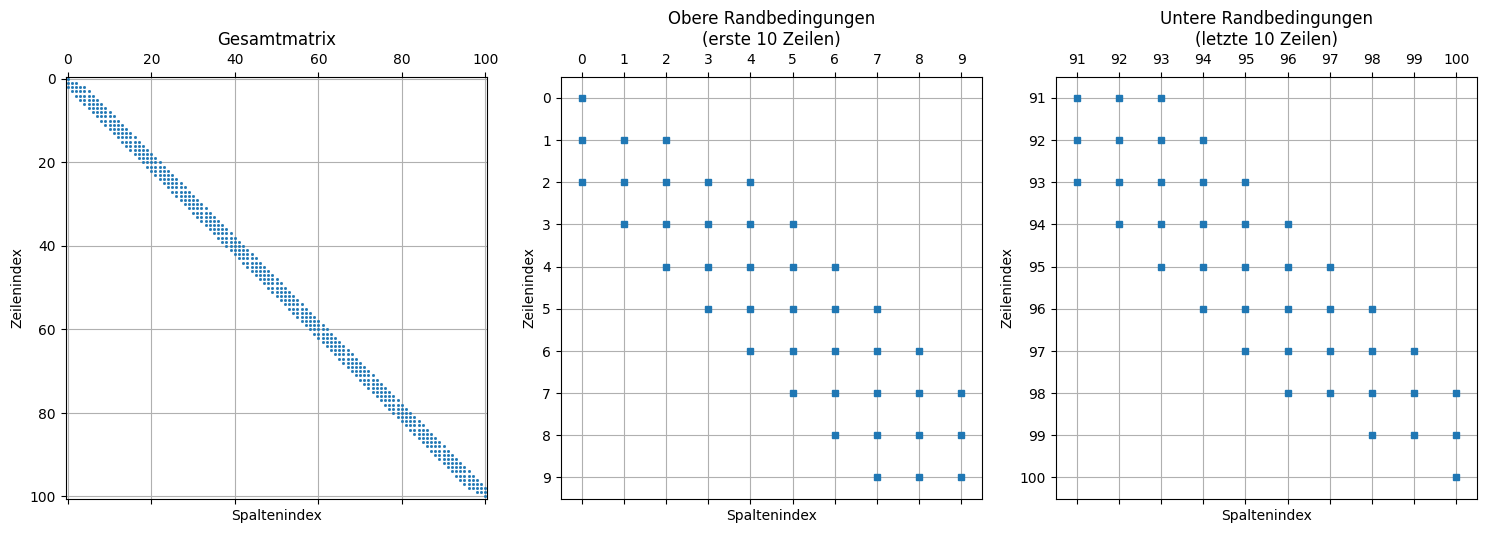

In [57]:
EIA1, _ = build_bending_matrix(N_nodes=100+1, h=0.01, EI=EI, q_c=q.copy(), boundary_condition="beidseitig_gelenkig")
plot_matrix_with_boundaries(EIA1)


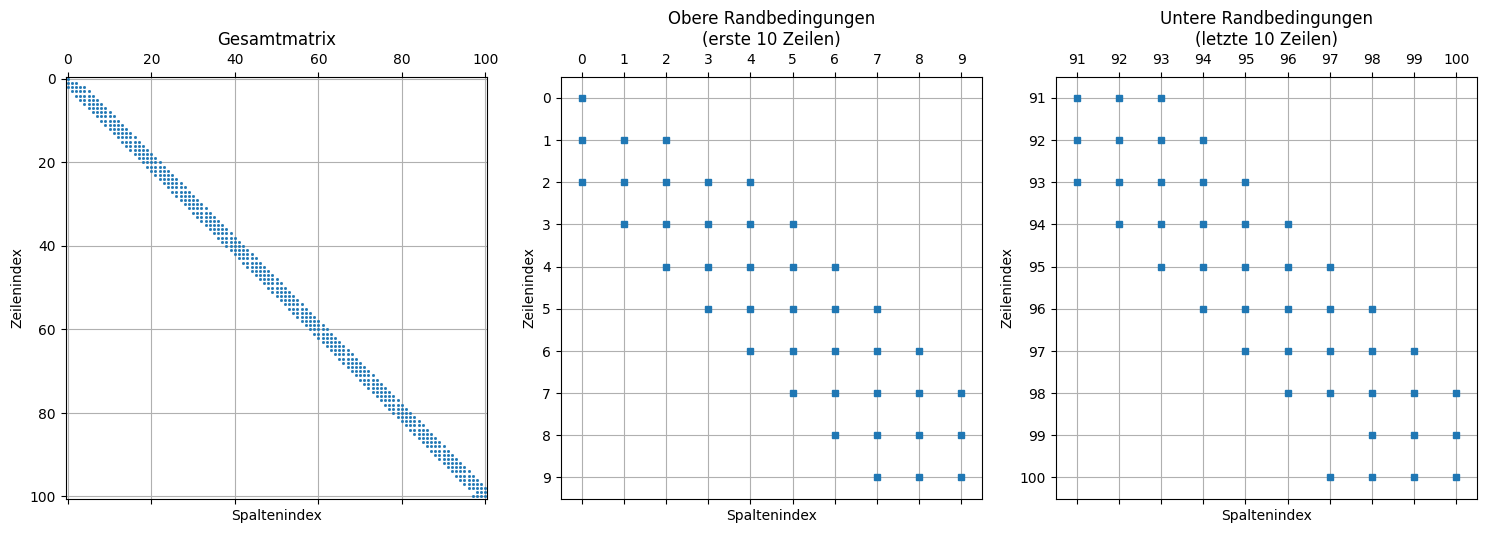

In [58]:
EIA2, _ = build_bending_matrix(N_nodes=100+1, h=0.01, EI=EI, q_c=q.copy(), boundary_condition="nur_links_eingespannt")
plot_matrix_with_boundaries(EIA2)

# Bedingung: w'''(L) = 0, Scherkraft am rechten Ende soll null sein
# Dritte Ableitung rückwärts differenziert (Rückwärts-Differenzformel):
# w'''(x_{N-1}) ≈ (-w_{N-4} + 2 w_{N-3} - 2 w_{N-2} + w_{N-1}) / (2 h^3) = 0

# print(A2[-1,range(-4,0,1)]*(2*h**3)) # die Koeffizienten sind [-1.  2. -2.  1.]


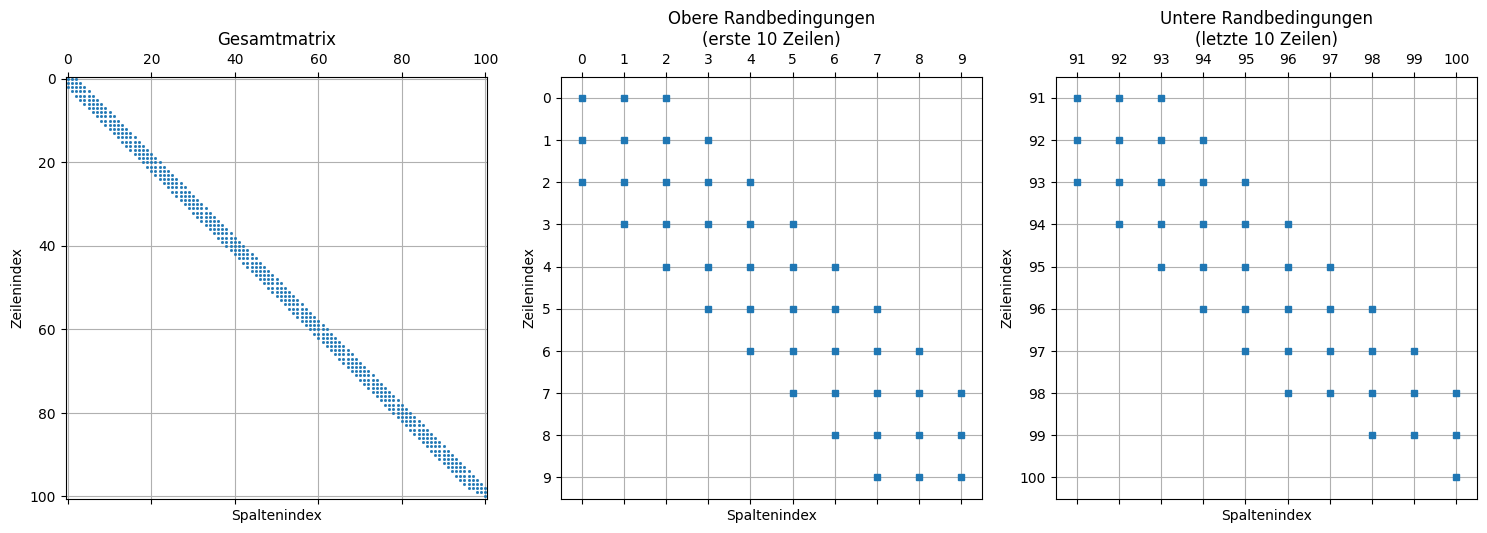

In [59]:
EIA3, _ = build_bending_matrix(N_nodes=100+1, h=0.01, EI=EI, q_c=q.copy(), boundary_condition="nur_rechts_eingespannt")
plot_matrix_with_boundaries(EIA3)


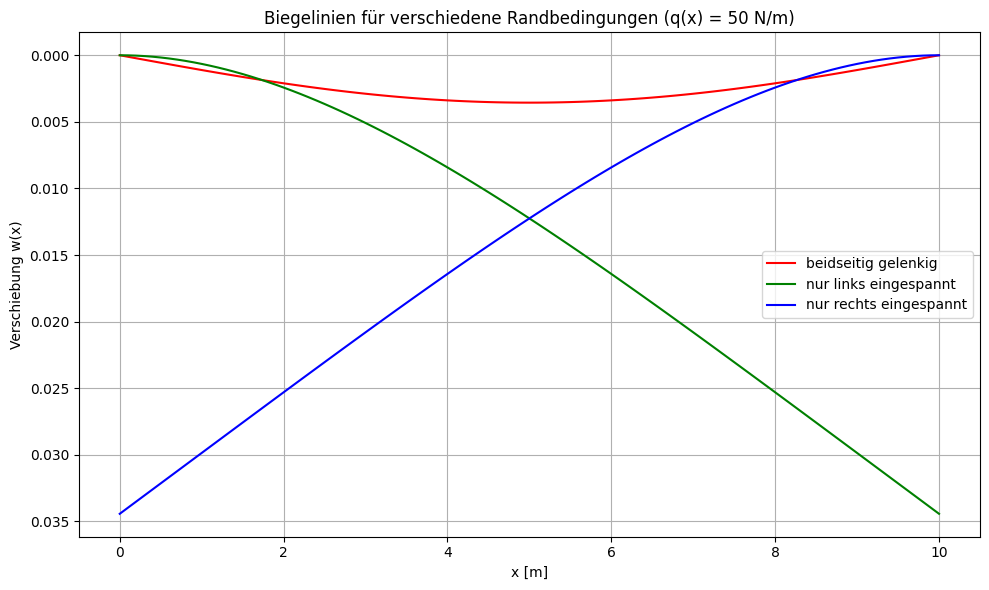

In [63]:
# -----------------------------------------------
# Vorbereitung der Lösung für verschiedene Randbedingungen
# -----------------------------------------------

# Liste der Randbedingungen, die wir betrachten wollen
boundary_conditions = {
    "beidseitig gelenkig": "beidseitig_gelenkig",
    "nur links eingespannt": "nur_links_eingespannt",
    "nur rechts eingespannt": "nur_rechts_eingespannt"
}

solutions = {}

# Schleife über alle Randbedingungen
for label, bc in boundary_conditions.items():
    EIA, q_mod = build_bending_matrix(N_nodes, h, EI, q.copy(), boundary_condition=bc)
    w = spsolve(EIA.tocsc(), q_mod) # https://stackoverflow.com/questions/32481829/compressed-sparse-column-csc-or-compressed-sparse-row-csr-sparse-matrix
    solutions[label] = w

# -----------------------------------------------
# Plot der Biegelinien
# -----------------------------------------------

plt.figure(figsize=(10, 6))

for (label, w), clr in zip(solutions.items(),beam_colors):
    plt.plot(x, w, label=label, color=clr)

plt.xlabel("x [m]")
plt.ylabel("Verschiebung w(x)")
plt.title(f"Biegelinien für verschiedene Randbedingungen (q(x) = {q0} N/m)")
plt.legend()
plt.grid(True)

# y-Achse invertieren, sodass sie von oben nach unten wächst
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()


Randbedingung: beidseitig_gelenkig - Relativer Fehler L2-Norm: 4.881e-02


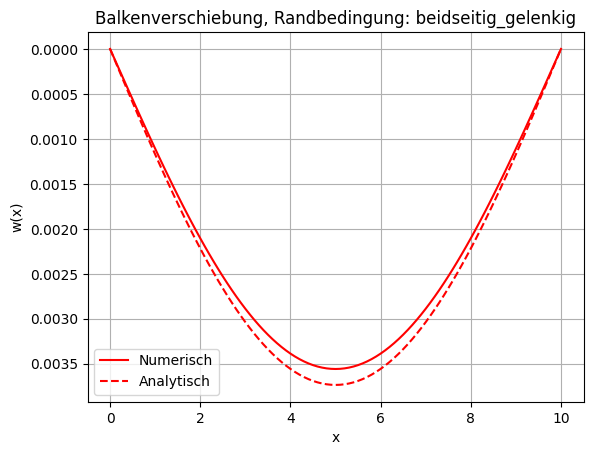

Randbedingung: nur_links_eingespannt - Relativer Fehler L2-Norm: 3.832e-02


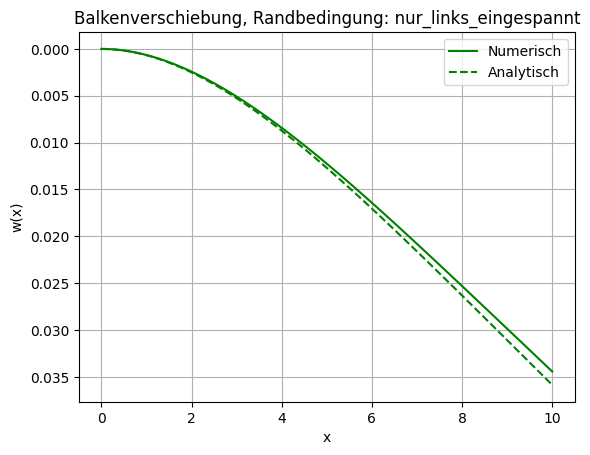

Randbedingung: nur_rechts_eingespannt - Relativer Fehler L2-Norm: 3.832e-02


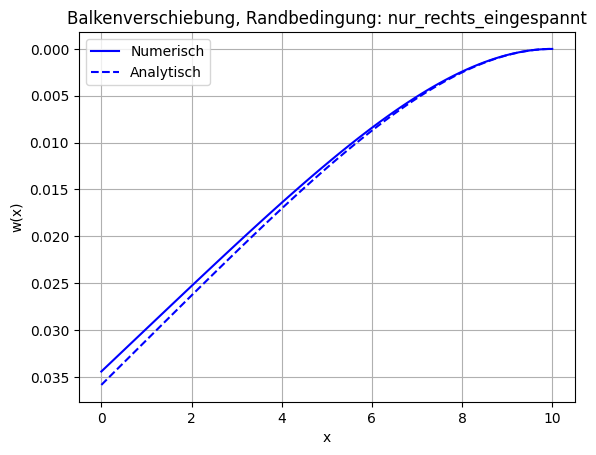

In [64]:
def analytical_solution_beidseitig_gelenkig(x, L, EI, q0):
    """Analytische Lösung für beidseitig gelenkigen Balken mit konstanter Last."""
    return (q0 / (24 * EI)) * x * (L**3 - 2*L*x**2 + x**3)

def analytical_solution_eingespannt_links(x, L, EI, q0):
    """Analytische Lösung für Balken mit links eingespannt und rechts frei."""
    return (q0/(24*EI)) * x**2 * (6*L**2 - 4*L*x + x**2)

def analytical_solution_eingespannt_rechts(x, L, EI, q0):
    """Analytische Lösung für Balken mit links frei und rechts eingespannt."""
    # Spiegelung von links eingespannt, frei rechts: w(x) = W(L-x)
    return analytical_solution_eingespannt_links(L - x, L, EI, q0)

def test_all_conditions():
    boundary_conditions = [
        "beidseitig_gelenkig",
        "nur_links_eingespannt",
        "nur_rechts_eingespannt"
    ]

    analytical_solutions = {
        "beidseitig_gelenkig": analytical_solution_beidseitig_gelenkig,
        "nur_links_eingespannt": analytical_solution_eingespannt_links,
        "nur_rechts_eingespannt": analytical_solution_eingespannt_rechts
    }

    for (bc, clr) in zip(boundary_conditions, beam_colors):
        A, q_adj = build_bending_matrix(N_nodes, h, EI, q.copy(), boundary_condition=bc)
        w_num = spsolve(A.tocsc(), q_adj) 

        # Hier q0 als Konstante übergeben, nicht q_adj (Vektor!)
        w_ana = analytical_solutions[bc](x, L, EI=EI, q0=q)

        err = np.linalg.norm(w_num - w_ana, ord=2) / np.linalg.norm(w_ana, ord=2)
        print(f"Randbedingung: {bc} - Relativer Fehler L2-Norm: {err:.3e}")

        plt.figure()
        plt.plot(x, w_num, color=clr, linestyle='solid', label='Numerisch')
        plt.plot(x, w_ana, color=clr, linestyle='dashed', label='Analytisch')
        plt.title(f"Balkenverschiebung, Randbedingung: {bc}")
        plt.xlabel('x')
        plt.ylabel('w(x)')
        plt.legend()

        # y-Achse invertieren, sodass sie von oben nach unten wächst
        plt.gca().invert_yaxis()

        plt.grid(True)
        plt.show()

test_all_conditions()
